## *Pepper Prices Analysis*

---

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"]=(20,10)
import seaborn as sns;sns.set()
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
from datetime import datetime,time
from plotly.offline import iplot,plot,init_notebook_mode,download_plotlyjs
%matplotlib inline 
init_notebook_mode(connected=True)

---

## *Importing data :*

In [2]:
df=pd.read_csv('Data_Sets/actual_data.csv')

---  
## *Data Over View :*

In [3]:
df.head()

,week_start_dt,week_end_dt,vietnam_season,p_color,price,total_volume,brazil,india,vietnam,indonesia,china,brazil_season,indonesia_season,india_season,china_season,jordan_max_price,jordan_min_price,demand,supply
0,2015-08-17,2015-08-23,1,yellow,7.249725,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,True,True,True,True,7.425,7.025,0.5,0.5
1,2015-08-17,2015-08-23,1,red,7.600215,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,True,True,True,True,8.125,7.825,0.5,0.5
2,2015-08-17,2015-08-23,1,green,7.074805,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,True,True,True,True,7.525,7.225,0.5,0.5
3,2015-08-24,2015-08-30,1,green,7.025085,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,True,True,True,True,7.425,7.225,0.5,0.5
4,2015-08-24,2015-08-30,1,red,7.722255,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,True,True,True,True,8.125,7.825,0.5,0.5


In [4]:
df.shape

(1272, 19)

---
# *Data Cleaning :*

* *We will :*  
*1. Remove the rows with value -1*  
*2. Na Values check*  
*3. Fiiling Na vlaues using interplolate with linear moethod*  
*4. Convert week_start_dt & week_end_dt to datetime datatype*  
*5. Detect numerical_cols,categorical_cols,boolean_cols, and date_cols*

* *Removing the rows with value -1*

In [5]:
df=df[df["total_volume"]!=-1]
df.shape

(1215, 19)

* *Na Values :*

In [6]:
print(f"The number of Na values is : {df.isna().sum().sum()}")
print("The number of Na values per column -if exist- is :")
df.isna().sum()

The number of Na values is : 62
The number of Na values per column -if exist- is :


week_start_dt        0
week_end_dt          0
vietnam_season       0
p_color              0
price                0
total_volume         0
brazil               0
india                0
vietnam              0
indonesia            0
china                0
brazil_season        0
indonesia_season     0
india_season         0
china_season         0
jordan_max_price    31
jordan_min_price    31
demand               0
supply               0
dtype: int64

* *Fiiling Na vlaues using interplolate with linear moethod*

In [7]:
df.interpolate(method="linear",inplace=True,limit_direction="backward")

In [8]:
print(f"The number of Na values is : {df.isna().sum().sum()}")

The number of Na values is : 0


* *dataset info :*

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1215 entries, 57 to 1271
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   week_start_dt     1215 non-null   object 
 1   week_end_dt       1215 non-null   object 
 2   vietnam_season    1215 non-null   int64  
 3   p_color           1215 non-null   object 
 4   price             1215 non-null   float64
 5   total_volume      1215 non-null   float64
 6   brazil            1215 non-null   float64
 7   india             1215 non-null   float64
 8   vietnam           1215 non-null   float64
 9   indonesia         1215 non-null   float64
 10  china             1215 non-null   float64
 11  brazil_season     1215 non-null   bool   
 12  indonesia_season  1215 non-null   bool   
 13  india_season      1215 non-null   bool   
 14  china_season      1215 non-null   bool   
 15  jordan_max_price  1215 non-null   float64
 16  jordan_min_price  1215 non-null   float64
 17 

* *Convert week_start_dt & week_end_dt to datetime datatype :*

In [10]:
df['week_start_dt']=pd.to_datetime(df['week_start_dt'])
df['week_end_dt']=pd.to_datetime(df['week_end_dt'])

* *Detect numerical_cols,categorical_cols,boolean_cols, and date_cols :*

In [11]:
numerical_cols=df.select_dtypes(include=np.number).columns.tolist()
categorical_cols=df.select_dtypes(include='object').columns.tolist()
boolean_cols=df.select_dtypes(include='bool').columns.tolist()
date_cols=df.select_dtypes(include='datetime').columns.tolist()

In [12]:
print(f"numerical_cols : \n{numerical_cols}")
print("--------------------------------------------------")
print(f"categorical_cols : \n{categorical_cols}")
print("--------------------------------------------------")
print(f"boolean_cols : \n{boolean_cols}")
print("--------------------------------------------------")
print(f"date_cols : \n{date_cols}")

numerical_cols : 
['vietnam_season', 'price', 'total_volume', 'brazil', 'india', 'vietnam', 'indonesia', 'china', 'jordan_max_price', 'jordan_min_price', 'demand', 'supply']
--------------------------------------------------
categorical_cols : 
['p_color']
--------------------------------------------------
boolean_cols : 
['brazil_season', 'indonesia_season', 'india_season', 'china_season']
--------------------------------------------------
date_cols : 
['week_start_dt', 'week_end_dt']


---
## *Feature Engeneering :*

*Create new features from existing ones : year,month_name,month,year_int,day_name,Weekday_Number,and DayOfMonth*

In [13]:
df_copy=df.copy()
df_copy["month"]=df_copy["week_start_dt"].dt.month
df_copy["year"]=df_copy["week_start_dt"].dt.year
df_copy["day_name"]=df_copy["week_start_dt"].dt.day_name()
df_copy['Weekday_Number'] = df_copy["week_start_dt"].dt.dayofweek
df_copy['DayOfMonth'] = df_copy['week_start_dt'].dt.day
df_copy.head()

,week_start_dt,week_end_dt,vietnam_season,p_color,price,total_volume,brazil,india,vietnam,indonesia,...,china_season,jordan_max_price,jordan_min_price,demand,supply,month,year,day_name,Weekday_Number,DayOfMonth
57,2015-12-28,2016-01-03,2,green,6.599075,1596040.2,10793.5,65658.1,1519588.5,0.0,...,False,6.625,6.325,0.50,0.5,12,2015,Monday,0,28
58,2015-12-28,2016-01-03,2,red,7.175335,1596040.2,10793.5,65658.1,1519588.5,0.0,...,False,7.525,7.125,0.51,0.5,12,2015,Monday,0,28
59,2015-12-28,2016-01-03,2,yellow,7.300575,1596040.2,10793.5,65658.1,1519588.5,0.0,...,False,7.425,7.025,16.55,0.5,12,2015,Monday,0,28
60,2016-01-04,2016-01-10,2,yellow,7.379675,2295578.0,5677.8,15274.4,2274625.7,0.0,...,False,7.525,7.025,271.16,0.5,1,2016,Monday,0,4
61,2016-01-04,2016-01-10,2,red,7.175335,2295578.0,5677.8,15274.4,2274625.7,0.0,...,False,7.625,7.125,42.33,0.5,1,2016,Monday,0,4


*will drop the day name as it has only one unique value for all*

In [14]:
df_copy=df_copy.drop(["day_name","Weekday_Number"],axis=1)

---  
## *Exploratory Data Analysis-EDA*

* *We will :*  
*1. have a quick look at the Number of unique values in each feature :*  
*2. numerical_cols EDA : distribution ,basic statistic summary,correlation and visualization*  
*3. categorical_cols EDA : distribution ,basic statistic summary and visualization*      
*4. boolean_cols EDA : distribution ,basic statistic summary and visualization*      
*5. Detect numerical_cols,categorical_cols,boolean_cols, and date_cols*

* *Number of unique values in each feature :*

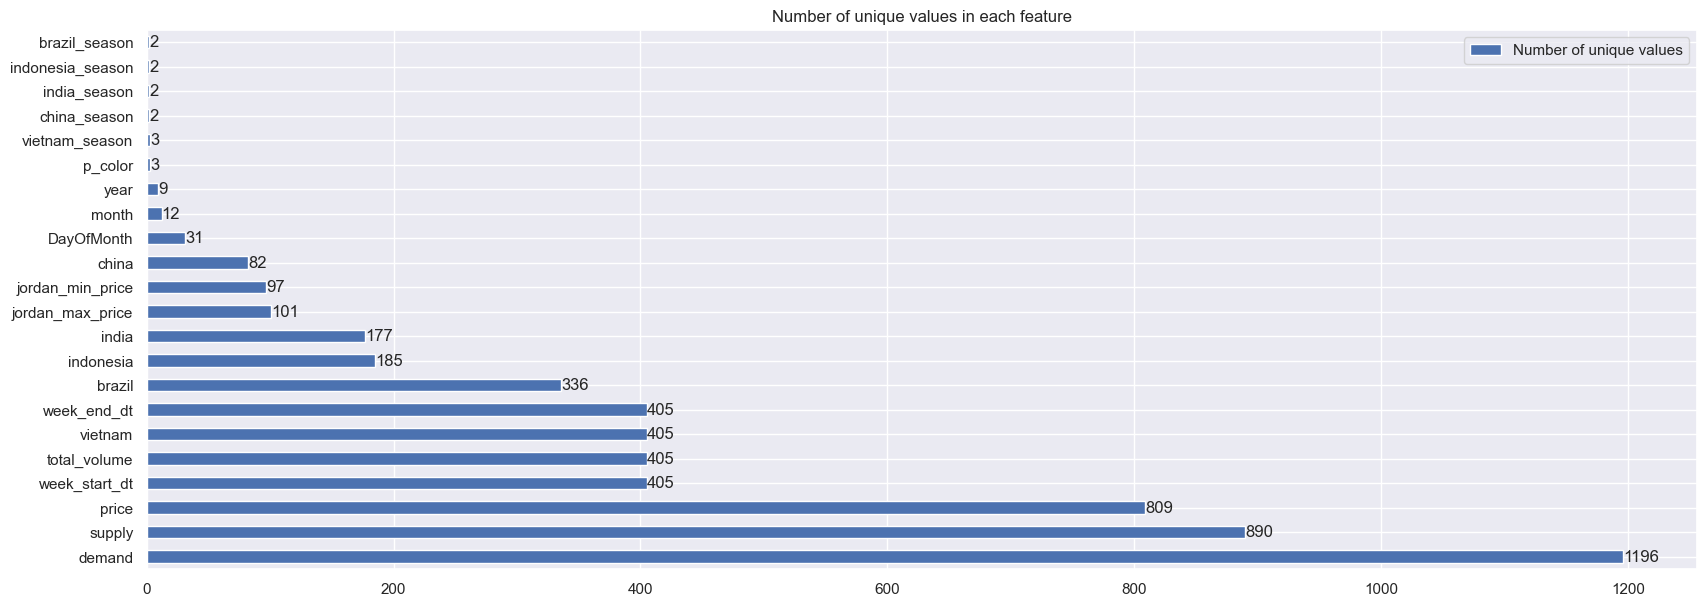

In [15]:
ax=df_copy.nunique().to_frame().rename(columns={0:"Number of unique values"}).sort_values(by="Number of unique values",
                                                                                  ascending=False).plot(kind="barh",figsize=(20,7),title="Number of unique values in each feature");

ax.bar_label(ax.containers[0]);

### *numerical_cols*

* *numerical_cols basic summary statistics :*

In [16]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
vietnam_season,1215.0,1.918519e+00,0.770616,1.000000,1.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00
price,1215.0,8.008801e+00,1.367471,6.299625,7.000047e+00,7.600120e+00,8.600505e+00,1.408459e+01
total_volume,1215.0,2.244701e+06,482013.003283,325471.000000,1.938246e+06,2.254902e+06,2.541123e+06,3.555979e+06
brazil,1215.0,2.453030e+05,238532.956065,0.000000,1.060860e+04,1.754931e+05,4.435506e+05,8.776478e+05
india,1215.0,2.874410e+04,55904.812350,0.000000,0.000000e+00,0.000000e+00,3.102260e+04,3.489974e+05
vietnam,1215.0,1.806530e+06,573830.707115,220121.500000,1.402234e+06,1.785219e+06,2.204095e+06,3.549175e+06
indonesia,1215.0,1.549481e+05,243242.278078,0.000000,0.000000e+00,2.150300e+03,2.784692e+05,1.061051e+06
china,1215.0,8.487645e+03,21366.041220,0.000000,0.000000e+00,0.000000e+00,7.257400e+03,2.109202e+05
jordan_max_price,1215.0,8.509403e+00,1.494271,6.225000,7.425000e+00,8.025000e+00,9.225000e+00,1.422500e+01
jordan_min_price,1215.0,7.926667e+00,1.367845,6.025000,6.925000e+00,7.525000e+00,8.525000e+00,1.372500e+01


* *Visalizing numerical_cols:*

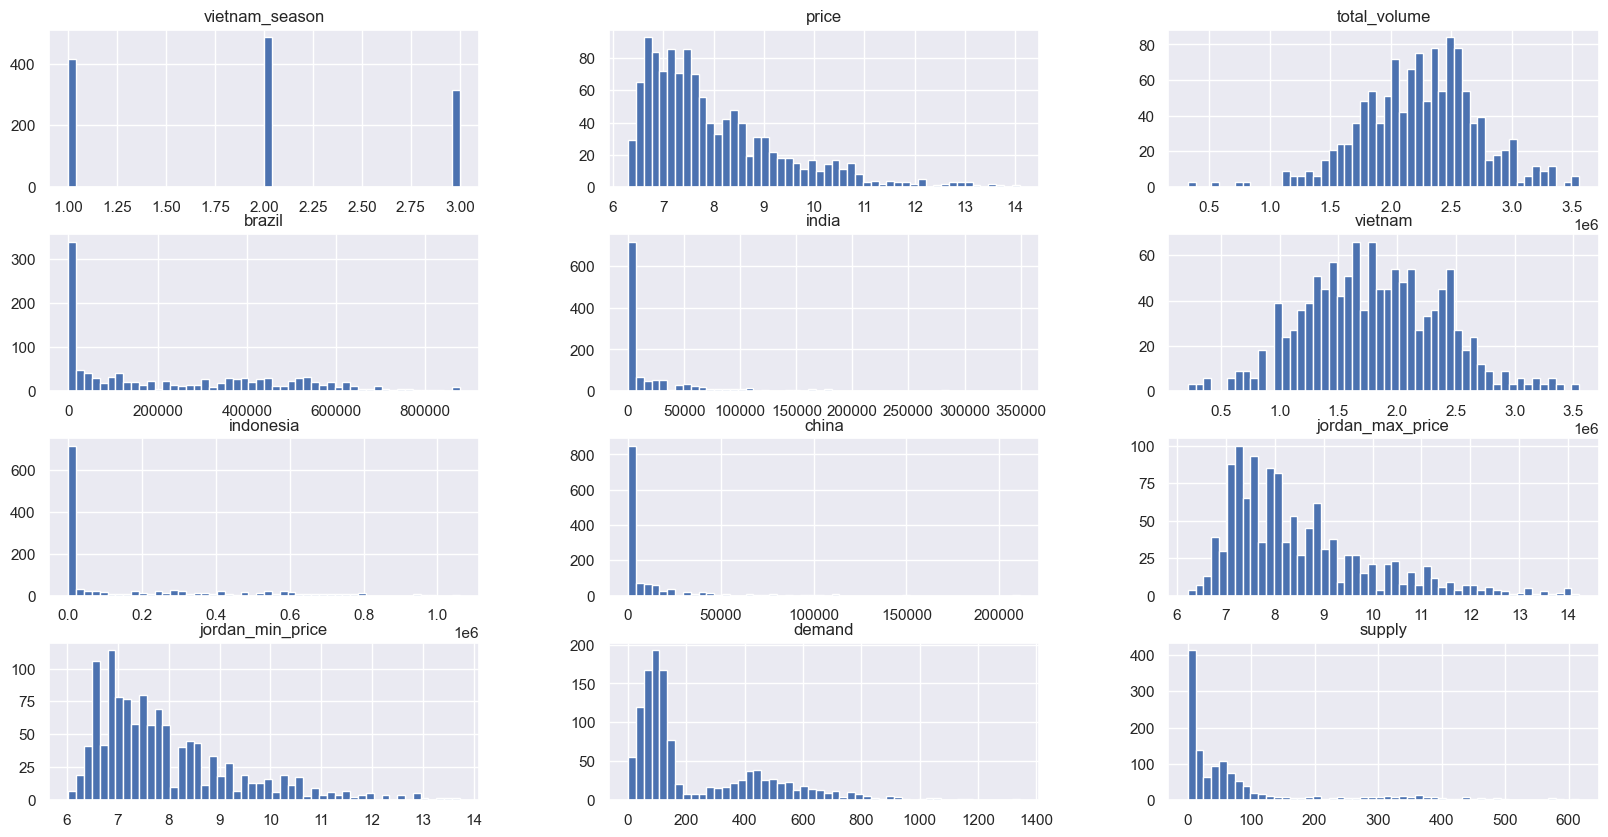

In [17]:
%matplotlib inline 
import matplotlib.pyplot as plt
df[numerical_cols].hist(bins=50, figsize=(20,10))
plt.show()

* *Define data distribution for numerical features :*

In [18]:
import scipy.stats as stats
distributions = ['norm', 'expon', 'gamma', 'lognorm', 'beta', 'uniform','logistic','triang','weibull_min','weibull_max','pareto']
def best_fit(df,distributions):
    best_fit = {}
    errors = []
    for i in numerical_cols:
        data = pd.to_numeric(df[i])
        for dist_name in distributions:
            dist = getattr(stats, dist_name)
            params = dist.fit(data)
            ks_stat, p_value = stats.kstest(data, dist_name, args=params)
            best_fit[dist_name] = p_value 
            #print(f"{dist_name}: p-value = {p_value:.4f}")

        best_distribution = max(best_fit, key=best_fit.get)
        print(f"Best fitting distribution for the feature {i}:==> {best_distribution} with p-value = {best_fit[best_distribution]:.4f}")  

best_fit(df=df,distributions=distributions)

Best fitting distribution for the feature vietnam_season:==> logistic with p-value = 0.0000
Best fitting distribution for the feature price:==> lognorm with p-value = 0.1280
Best fitting distribution for the feature total_volume:==> lognorm with p-value = 0.1775
Best fitting distribution for the feature brazil:==> norm with p-value = 0.0000
Best fitting distribution for the feature india:==> norm with p-value = 0.0000
Best fitting distribution for the feature vietnam:==> beta with p-value = 0.5312
Best fitting distribution for the feature indonesia:==> logistic with p-value = 0.0000
Best fitting distribution for the feature china:==> norm with p-value = 0.0000
Best fitting distribution for the feature jordan_max_price:==> lognorm with p-value = 0.0143
Best fitting distribution for the feature jordan_min_price:==> lognorm with p-value = 0.0020
Best fitting distribution for the feature demand:==> lognorm with p-value = 0.0000
Best fitting distribution for the feature supply:==> norm with

* *numerical_cols correlation using kendall method*

In [19]:
corr_matrix = df[numerical_cols].corr(method='kendall')
corr_matrix

,vietnam_season,price,total_volume,brazil,india,vietnam,indonesia,china,jordan_max_price,jordan_min_price,demand,supply
vietnam_season,1.000000,-0.110692,0.076351,0.036626,-0.088580,0.263041,-0.416143,-0.139930,-0.133001,-0.111500,0.033630,0.021674
price,-0.110692,1.000000,-0.074086,0.191875,-0.018944,-0.238479,0.264413,0.048962,0.876552,0.882043,0.280564,0.043531
total_volume,0.076351,-0.074086,1.000000,0.127569,-0.258146,0.522234,0.042517,0.262401,-0.081399,-0.063816,0.075580,0.362152
brazil,0.036626,0.191875,0.127569,1.000000,-0.469476,-0.259652,0.407216,0.064724,0.168929,0.175993,0.020222,0.027132
india,-0.088580,-0.018944,-0.258146,-0.469476,1.000000,0.040480,-0.325707,-0.245752,-0.000441,-0.010598,-0.068415,-0.261851
vietnam,0.263041,-0.238479,0.522234,-0.259652,0.040480,1.000000,-0.411314,0.065032,-0.243133,-0.222723,0.069731,0.275957
indonesia,-0.416143,0.264413,0.042517,0.407216,-0.325707,-0.411314,1.000000,0.243741,0.263802,0.258077,-0.001360,0.065183
china,-0.139930,0.048962,0.262401,0.064724,-0.245752,0.065032,0.243741,1.000000,0.050357,0.053948,0.006198,0.398490
jordan_max_price,-0.133001,0.876552,-0.081399,0.168929,-0.000441,-0.243133,0.263802,0.050357,1.000000,0.909464,0.269733,0.046322
jordan_min_price,-0.111500,0.882043,-0.063816,0.175993,-0.010598,-0.222723,0.258077,0.053948,0.909464,1.000000,0.289573,0.055633


* *numerical_cols correlation heatmap*

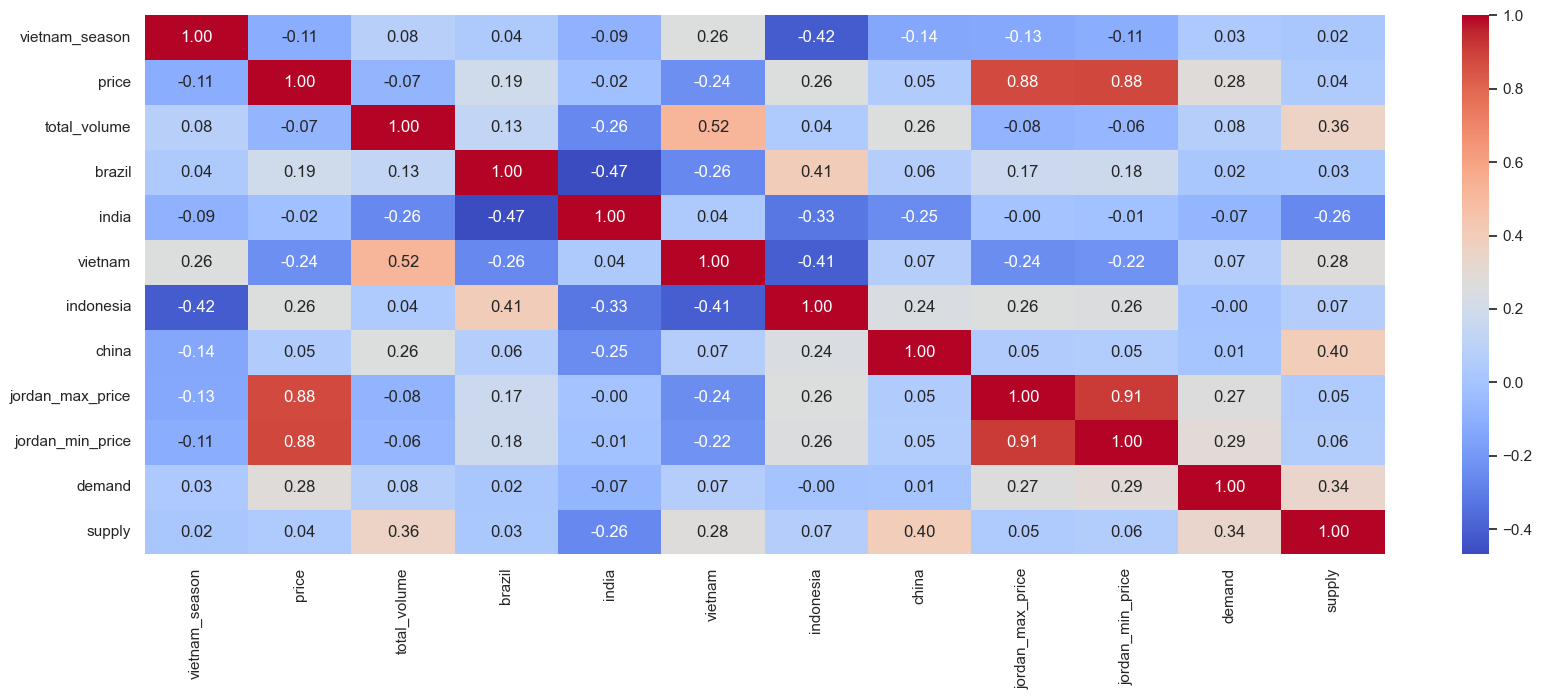

In [20]:
plt.figure(figsize=(20,7))
ax=sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f");

* *corr_matrix -Price as target feature*

In [21]:
corr_matrix["price"].sort_values(ascending=False)

price               1.000000
jordan_min_price    0.882043
jordan_max_price    0.876552
demand              0.280564
indonesia           0.264413
brazil              0.191875
china               0.048962
supply              0.043531
india              -0.018944
total_volume       -0.074086
vietnam_season     -0.110692
vietnam            -0.238479
Name: price, dtype: float64

* *Visualizing corr_matrix -Price as target feature*

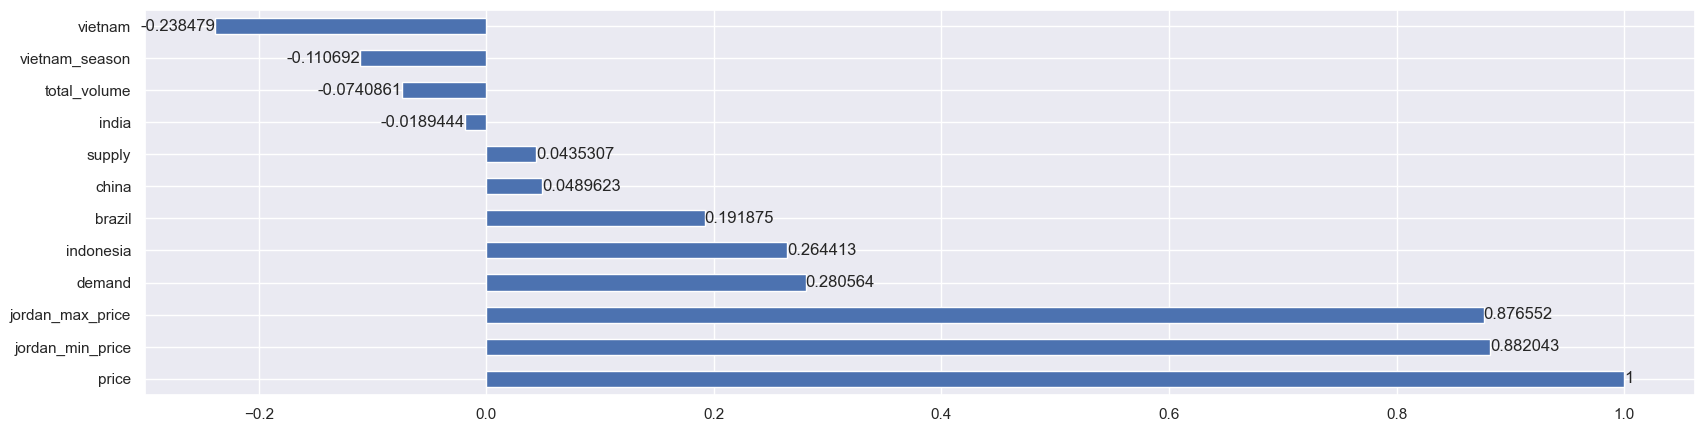

In [20]:
plt.figure(figsize=(20,5))
ax=corr_matrix["price"].sort_values(ascending=False).plot(kind='barh')
ax.bar_label(ax.containers[0]);

### *Categorical features :*

* *categorical_cols basic summary statistics :*

In [49]:
df[categorical_cols].describe().T

,count,unique,top,freq
p_color,1272,3,yellow,424


* *Visalizing categorical_cols:*

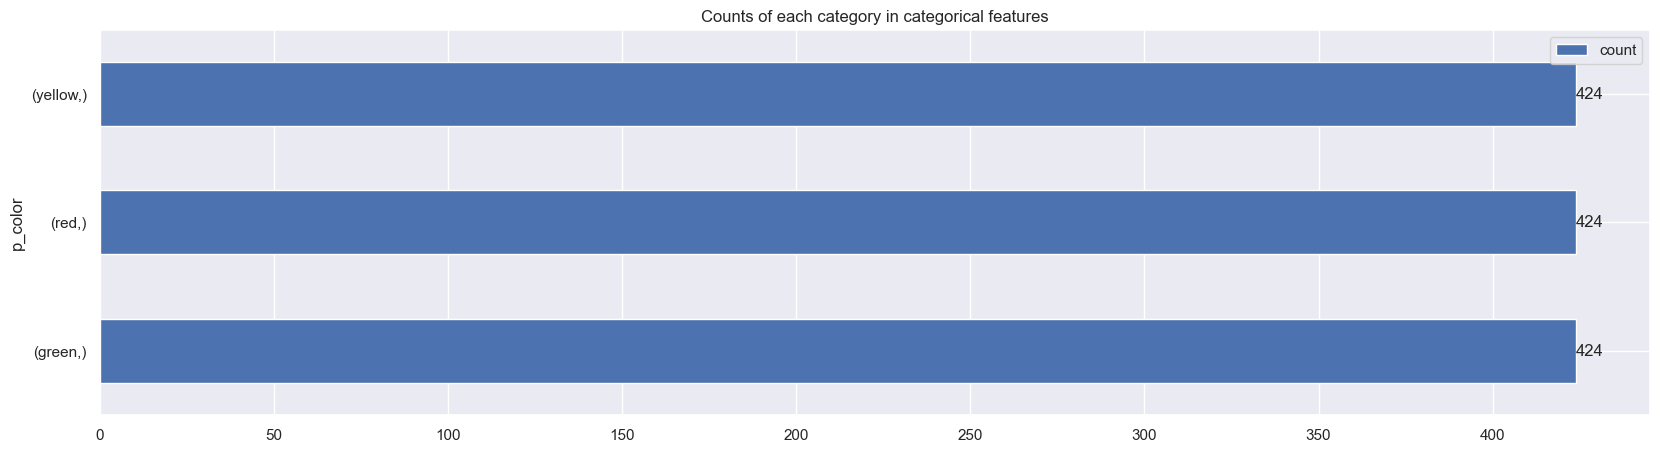

In [51]:
ax=df[categorical_cols].value_counts().to_frame().rename(columns={0:"Counts"}).plot(kind="barh",figsize=(20,5),title="Counts of each category in categorical features")
ax.bar_label(ax.containers[0]);

### *boolean features :*

* *boolean_cols basic summary statistics :*

In [99]:
df[boolean_cols].describe()

,brazil_season,indonesia_season,india_season,china_season
count,1215,1215,1215,1215
unique,2,2,2,2
top,False,False,False,False
freq,690,903,912,801


* *Visalizing boolean_cols:*

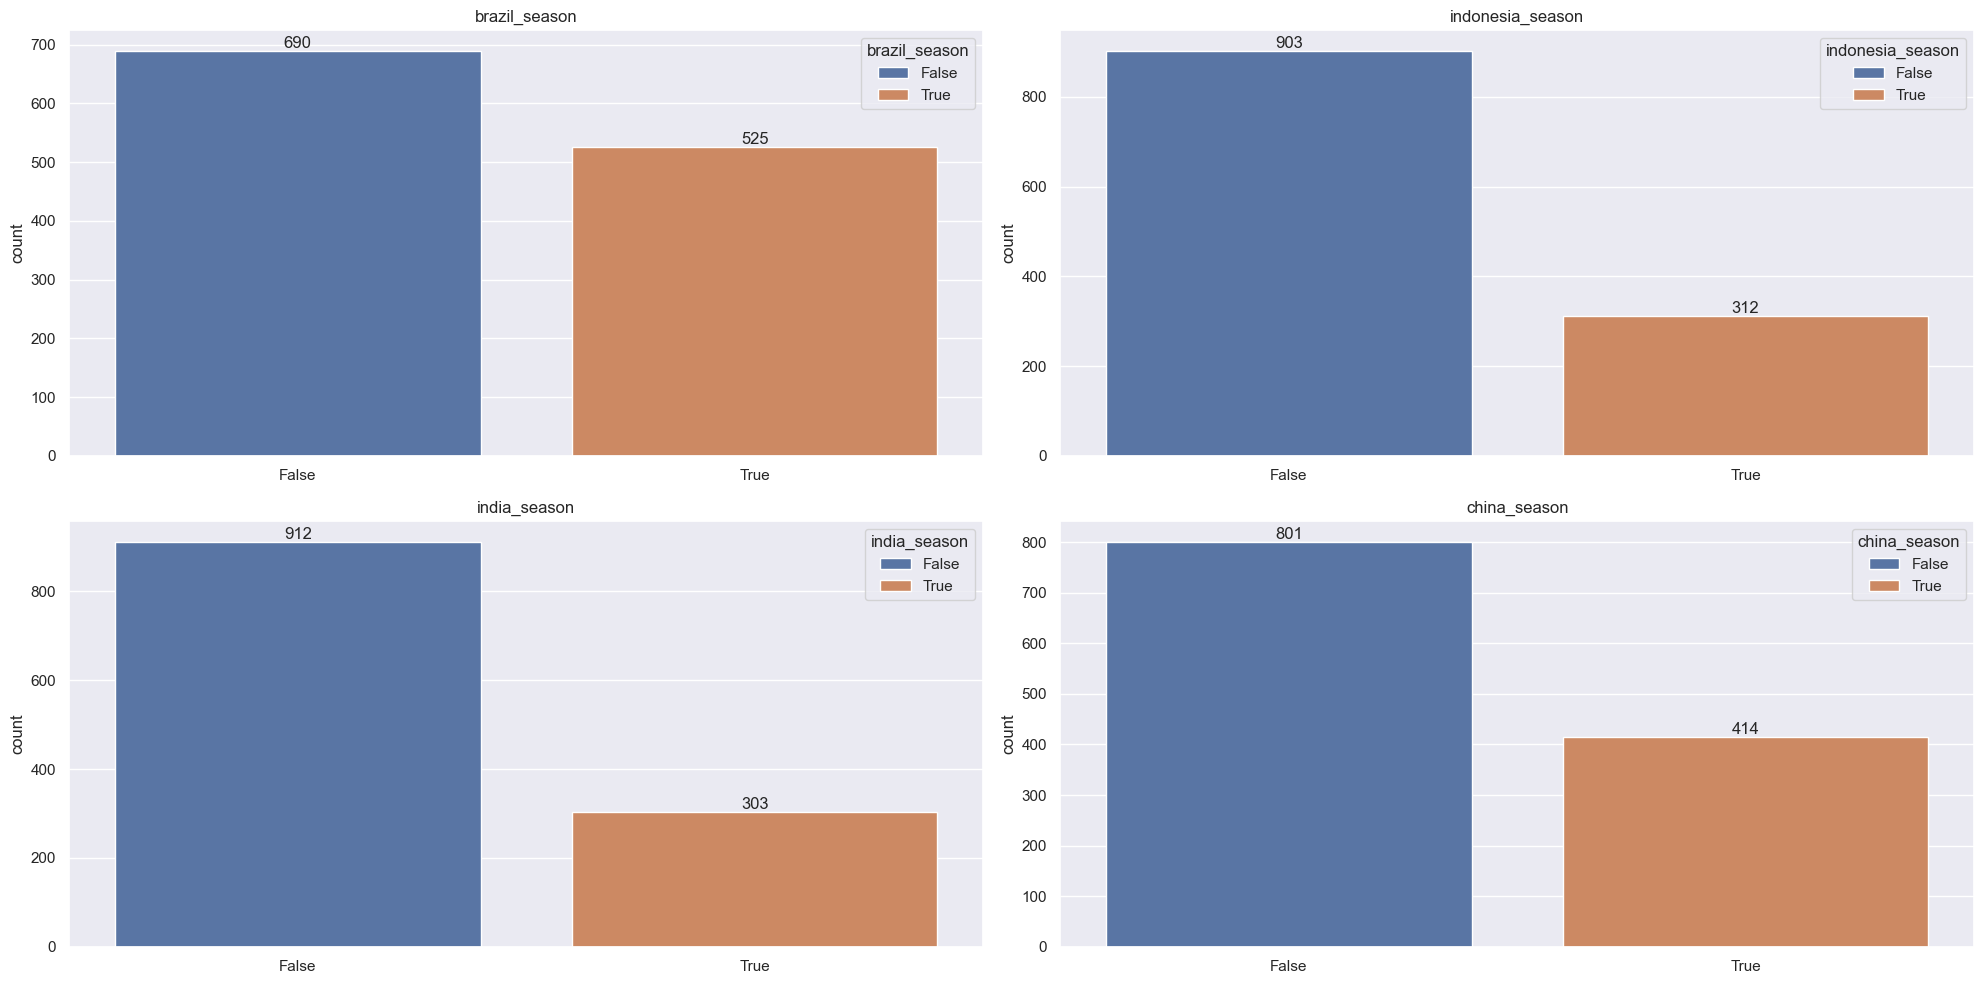

In [305]:
%matplotlib inline 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
sns.countplot(data=df, x="brazil_season", ax=ax1,hue='brazil_season')
ax1.set_title("brazil_season")
ax1.set_xlabel("")
for container in ax1.containers:
    ax1.bar_label(container)

ax2 = fig.add_subplot(gs[0, 1])
Area_order=['A','B','C','D','E','F']
sns.countplot(data=df, x="indonesia_season", ax=ax2,hue='indonesia_season')
ax2.set_title("indonesia_season")
ax2.set_xlabel("")
for container in ax2.containers:
    ax2.bar_label(container)

ax3 = fig.add_subplot(gs[1, 0])
sns.countplot(data=df, x="india_season", ax=ax3,hue='india_season')
ax3.set_title("india_season")
ax3.set_xlabel("")
for container in ax3.containers:
    ax3.bar_label(container) 


ax4 = fig.add_subplot(gs[1, 1])
sns.countplot(data=df, x="china_season", ax=ax4,hue='china_season')
ax4.set_title("china_season")
ax4.set_xlabel("")
for container in ax4.containers:
    ax4.bar_label(container)  


plt.tight_layout()
plt.show()

---
* *Seasons Overlaping :*  
*We will find out how seasons overlap with each other*

In [22]:
df_copy2=df_copy.copy()
df_copy2[['brazil_season', 'indonesia_season', 'india_season', 'china_season']]=df_copy2[['brazil_season', 'indonesia_season', 'india_season', 'china_season']].astype("int")
df_seasons=df_copy2[['month','vietnam_season','brazil_season','india_season','china_season','indonesia_season']]

In [23]:
df_seasons.groupby(['month','vietnam_season','india_season','china_season','indonesia_season','brazil_season']).count()

Empty DataFrame
Columns: []
Index: [(1, 2, 0, 0, 0, 0), (2, 2, 0, 0, 0, 0), (3, 3, 0, 0, 0, 0), (3, 3, 0, 0, 0, 1), (4, 3, 0, 0, 0, 1), (5, 3, 0, 0, 0, 1), (5, 3, 0, 1, 1, 1), (6, 1, 0, 1, 1, 1), (7, 1, 0, 1, 1, 1), (7, 1, 1, 1, 1, 1), (8, 1, 1, 1, 0, 0), (8, 1, 1, 1, 1, 1), (9, 1, 1, 0, 0, 0), (9, 1, 1, 1, 0, 0), (10, 2, 0, 0, 0, 0), (10, 2, 1, 0, 0, 0), (11, 2, 0, 0, 0, 0), (12, 2, 0, 0, 0, 0)]

* *Visualizing Seasons Overlaping-heatmap :*  

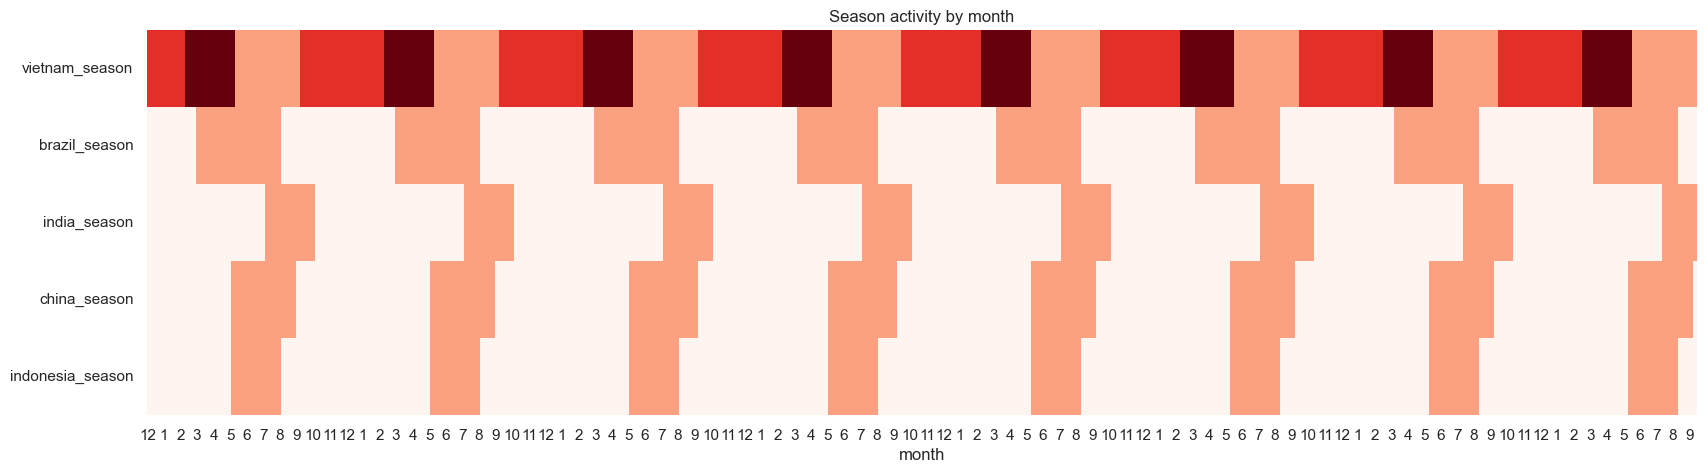

In [21]:
import seaborn as sns
plt.subplots(figsize=(20,5))
sns.heatmap(df_seasons.set_index('month').T, cmap="Reds", cbar=False)
plt.title("Season activity by month")
plt.show()


* *Visualizing Seasons Overlaping-barplots :*  

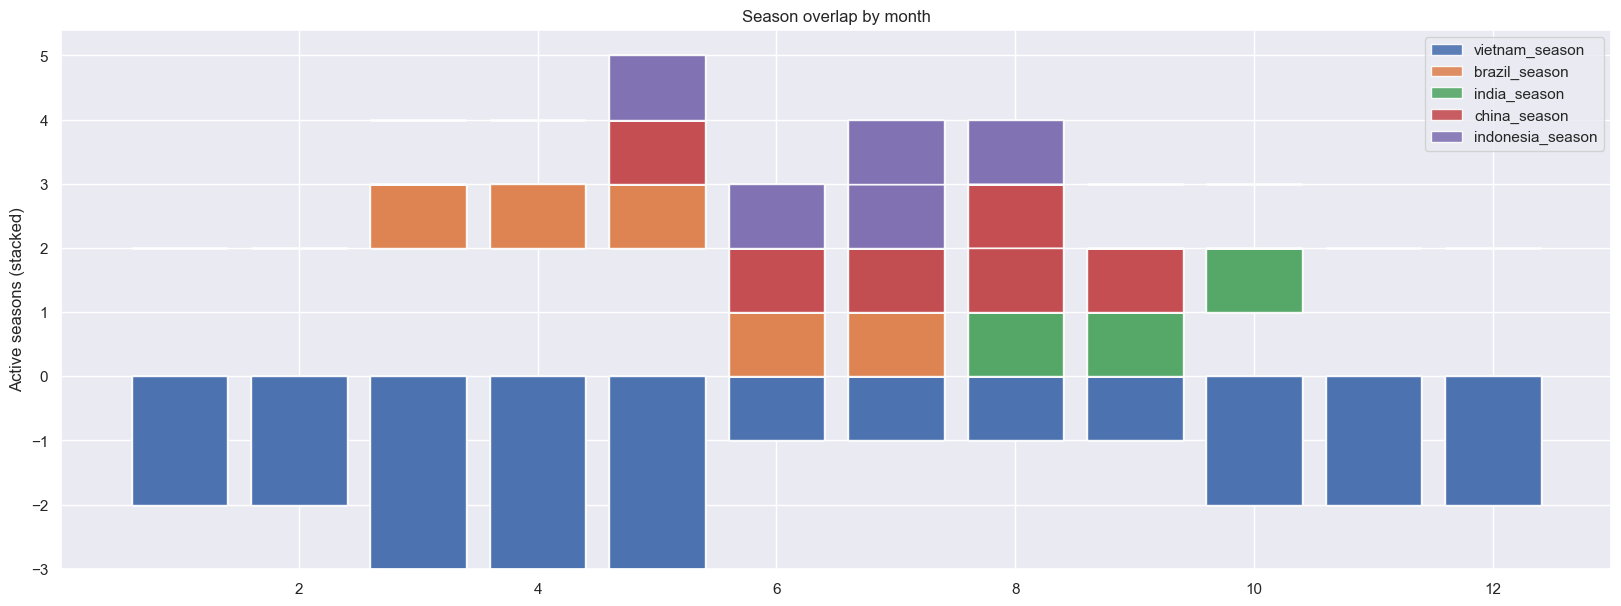

In [40]:
fig, ax = plt.subplots(figsize=(20, 7))
for i, season in enumerate(['vietnam_season', 'brazil_season', 'india_season','china_season','indonesia_season']):
    ax.bar(df_seasons['month'], df_seasons[season], bottom=df_seasons.iloc[:, 1:i+1].sum(axis=1)-df_seasons[season],
          label=season, alpha=0.9)

ax.legend()
ax.set_ylabel("Active seasons (stacked)")
#ax.set_yticklabels("")

plt.title("Season overlap by month")
plt.show()

---
## *probabilities*

*As our target is the price feature we will only be focusing on*  
*--> The below used fcuntions are stred in util.ipynb notebook , we have seperated them in order to make this notebook clear*

In [24]:
import import_ipynb
from utils import *

* *Price empirical probability*

In [25]:
price_conditional_empirical_prob_all(df=df_copy, price_col="price", threshold=10)

,Condition,P(price > 10),P(price < 10),P(price = 10),P(price >= 10),P(price <= 10)
0,All,0.102058,0.897942,0.0,0.102058,0.897942


* *Price conditional empirical probability*

In [26]:
price_conditional_empirical_prob_all(df=df_copy, price_col="price", threshold=10, category_col="p_color")

,p_color,P(price > 10),P(price < 10),P(price = 10),P(price >= 10),P(price <= 10)
0,green,0.004938,0.995062,0.0,0.004938,0.995062
1,red,0.069136,0.930864,0.0,0.069136,0.930864
2,yellow,0.232099,0.767901,0.0,0.232099,0.767901


* *Price distribution probability*

In [27]:
price_conditional_distribution_prob_all(df=df_copy, price_col="price", threshold=10, dist="lognormal")

,Condition,P(price > 10),P(price < 10),P(price >= 10),P(price <= 10),P(price = 10)
0,All,0.067699,0.932301,0.067699,0.932301,0.0


* *Price conditional distribution probability*

In [28]:
price_conditional_distribution_prob_all(df=df_copy, price_col="price", threshold=10, category_col="p_color", dist="lognormal")

,p_color,P(price > 10),P(price < 10),P(price >= 10),P(price <= 10),P(price = 10)
0,green,0.000721,0.999279,0.000721,0.999279,0.0
1,red,0.032904,0.967096,0.032904,0.967096,0.0
2,yellow,0.207943,0.792057,0.207943,0.792057,0.0


---

## *Inferential statistics*  
* *Hypothesis testing*

*Checking the Target feature-Price- normality*

In [27]:
from scipy.stats import shapiro
import scipy.stats as stats   
def normaly_distibuted_check(data,column):
    from scipy.stats import shapiro
    stat, p = shapiro(data[column])
    print(f"W = {stat:.3f}, p = {p:.3f}")
    if p < 0.05:
        print("Reject H₀ → distribution is not normal")
    else:
        print("Fail to reject H₀ → distribution is compatible with normality")
  
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))   
    sns.boxplot(data=data, x=column, ax=axes[0])
    axes[0].set_title(f'{column} Boxplot')  
    sns.histplot(data=data, x=column, ax=axes[1])
    axes[1].set_title(f'{column} histogram') 
    stats.probplot(data[column], dist="norm", plot=plt)
    axes[2].set_title(f'{column} qq-plot')   

W = 0.877, p = 0.000
Reject H₀ → distribution is not normal


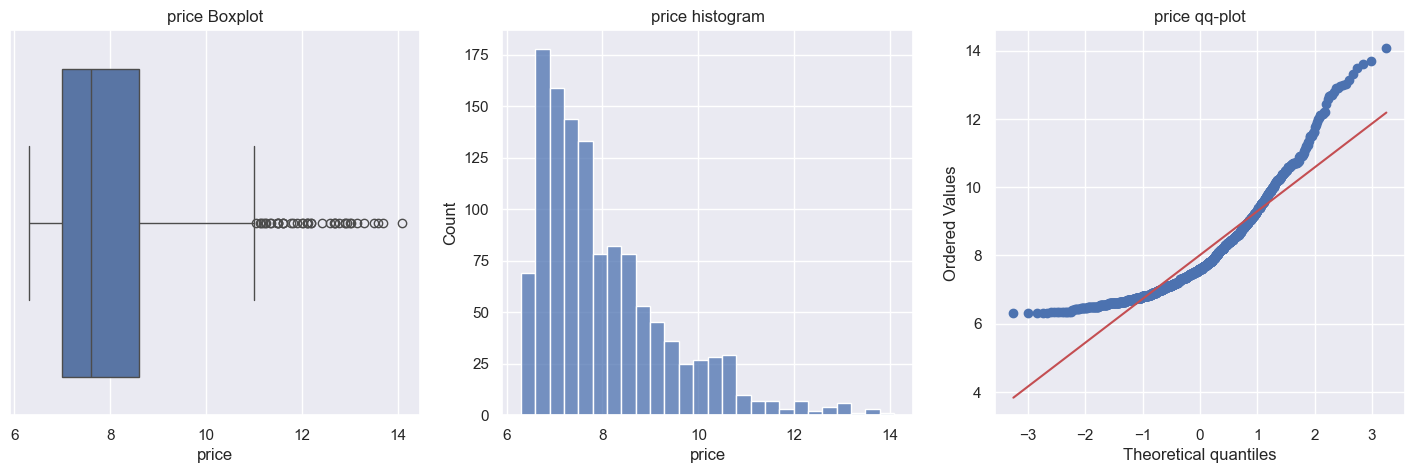

In [28]:
normaly_distibuted_check(data=df_copy,column="price")

---

* *As the Target feature-Price is not normaly distributed , we will apply non-parametric statistical tests*

--> *Null hypothesis :There is no significant relationship / distribution difference between the P-value shoud be > .05*  
--> *Alternatice hypothesis :There is significant relationship / distribution difference between the P-value shoud be < .05*

* *Mann-Whitney U test --> non-parametric statistical test used when we have non-normaly distributed target feature and Binary inpute Feature*

W = 115126.000, p = 0.000
As The P-value is less than .05 : Reject H₀ → There is significant distribution difference between price & brazil_season


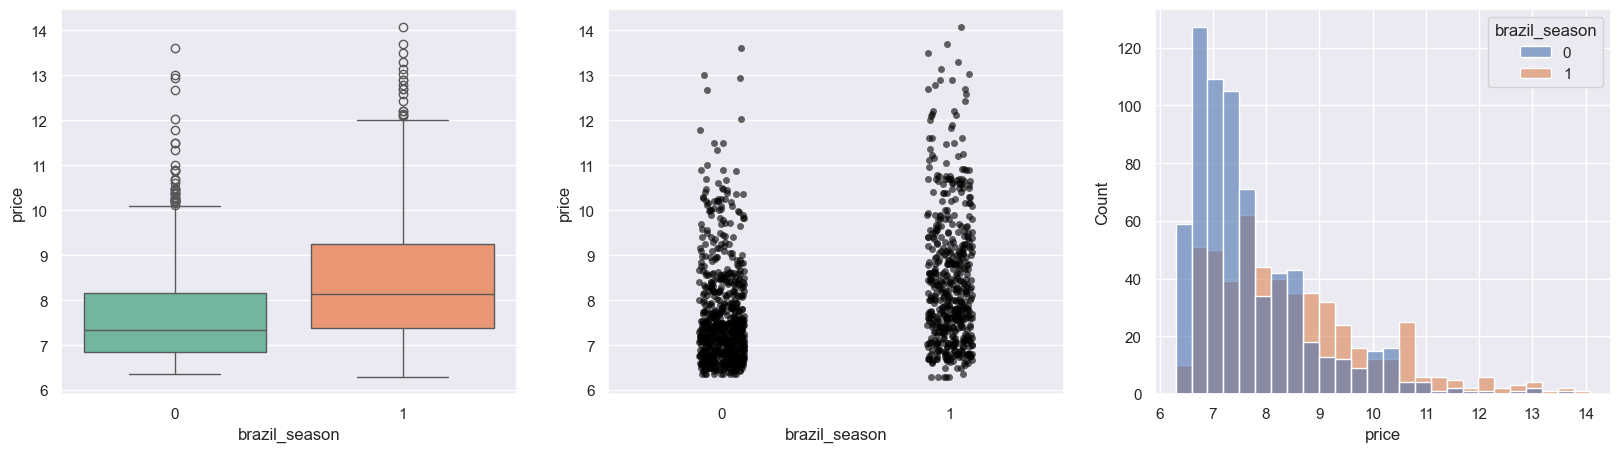

In [29]:
mannwhitneyu_func(Dataset=df_copy2,Numericaltarget="price",BinaryFeature="brazil_season")

W = 89565.500, p = 0.000
As The P-value is less than .05 : Reject H₀ → There is significant distribution difference between price & indonesia_season


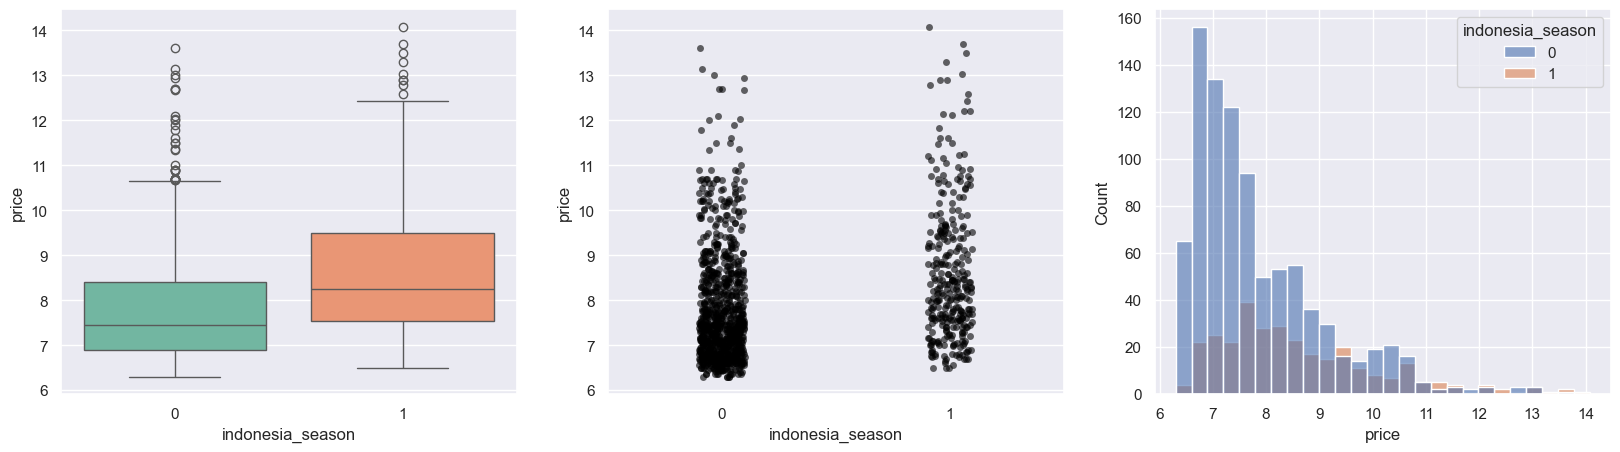

In [30]:
mannwhitneyu_func(Dataset=df_copy2,Numericaltarget="price",BinaryFeature="indonesia_season")

W = 116426.000, p = 0.000
As The P-value is less than .05 : Reject H₀ → There is significant distribution difference between price & india_season


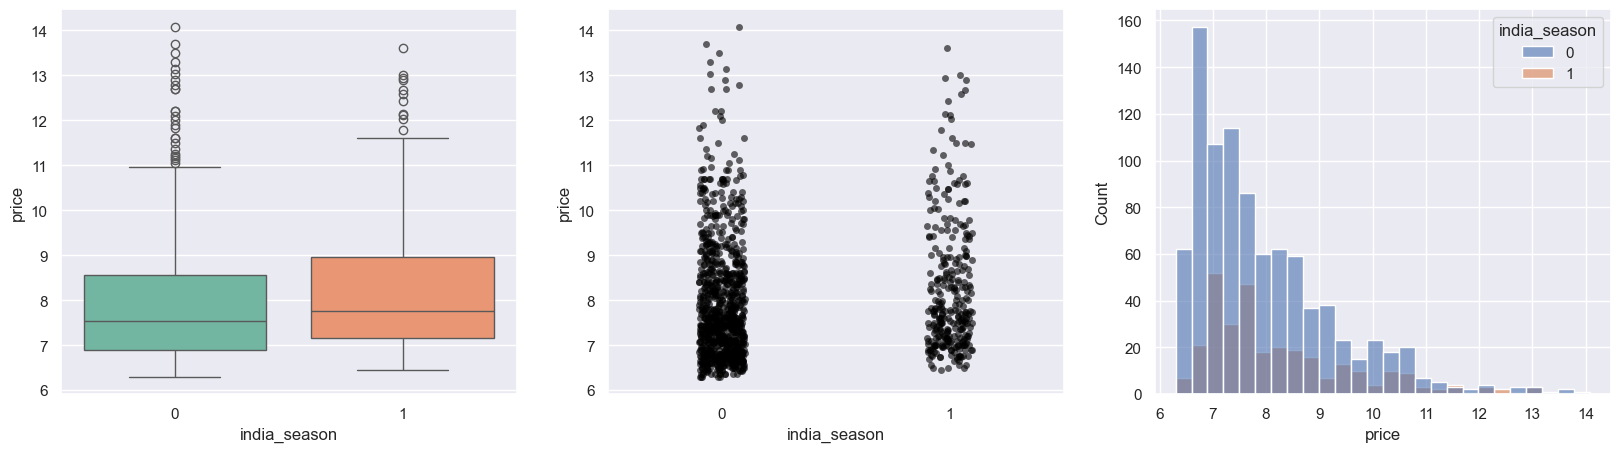

In [31]:
mannwhitneyu_func(Dataset=df_copy2,Numericaltarget="price",BinaryFeature="india_season")

W = 105169.500, p = 0.000
As The P-value is less than .05 : Reject H₀ → There is significant distribution difference between price & china_season


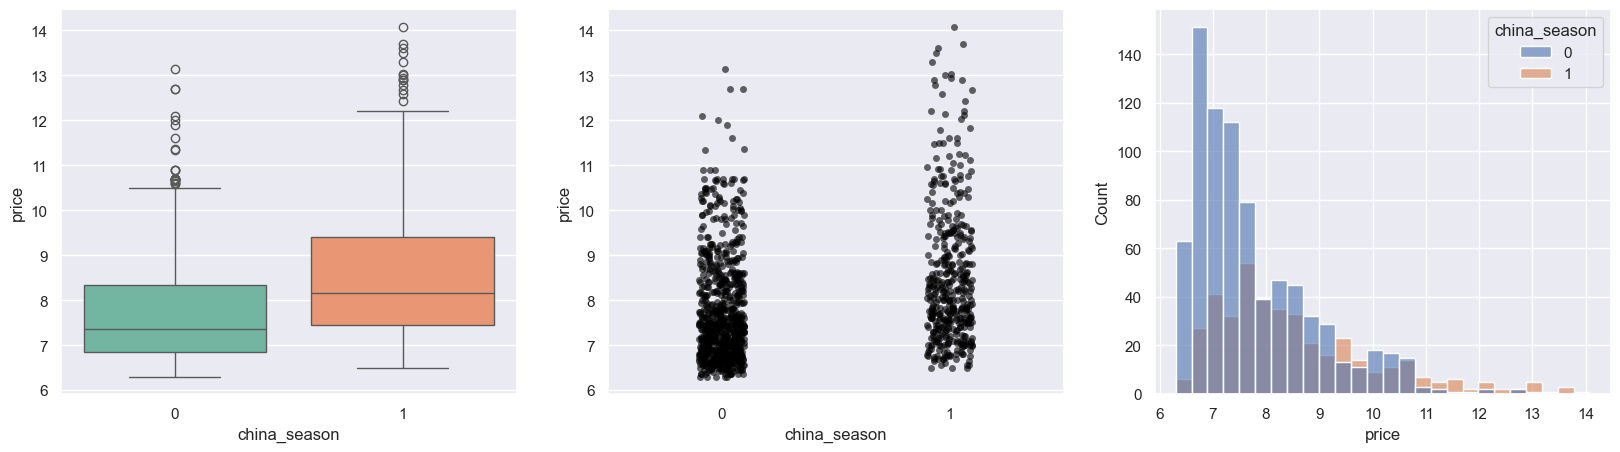

In [32]:
mannwhitneyu_func(Dataset=df_copy2,Numericaltarget="price",BinaryFeature="china_season")

* *Spearman's rank correlation test --> non-parametric statistical test used when we have non-normaly distributed target feature and Ordinal inpute Feature to test the monotonic relationship*

W = -0.143, p = 0.000
As The P-value is less than .05 : Reject H₀ → There is significant monotonic relationship between price & vietnam_season


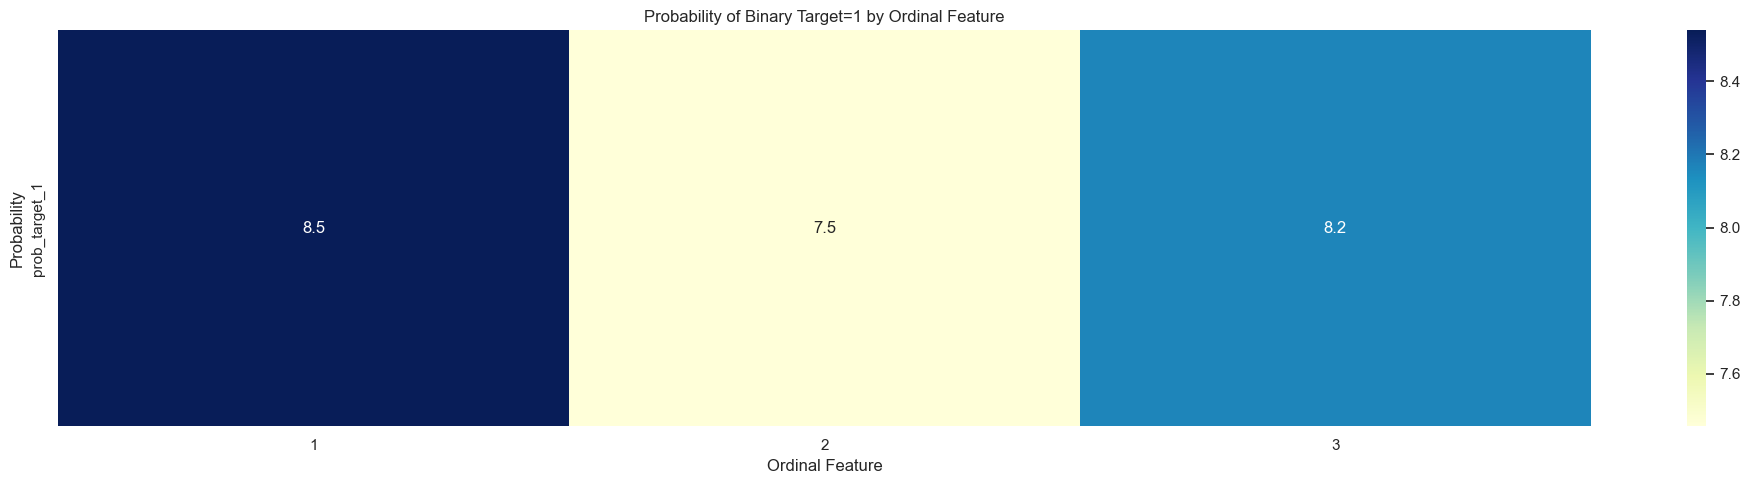

In [33]:
spearmanr_func(Dataset=df_copy2,Numericaltarget="price",OrdinalFeature="vietnam_season")

W = -0.009, p = 0.762
As The P-value is more than .05 : Fail to reject H₀ → No significant monotonic relationship between price & DayOfMonth


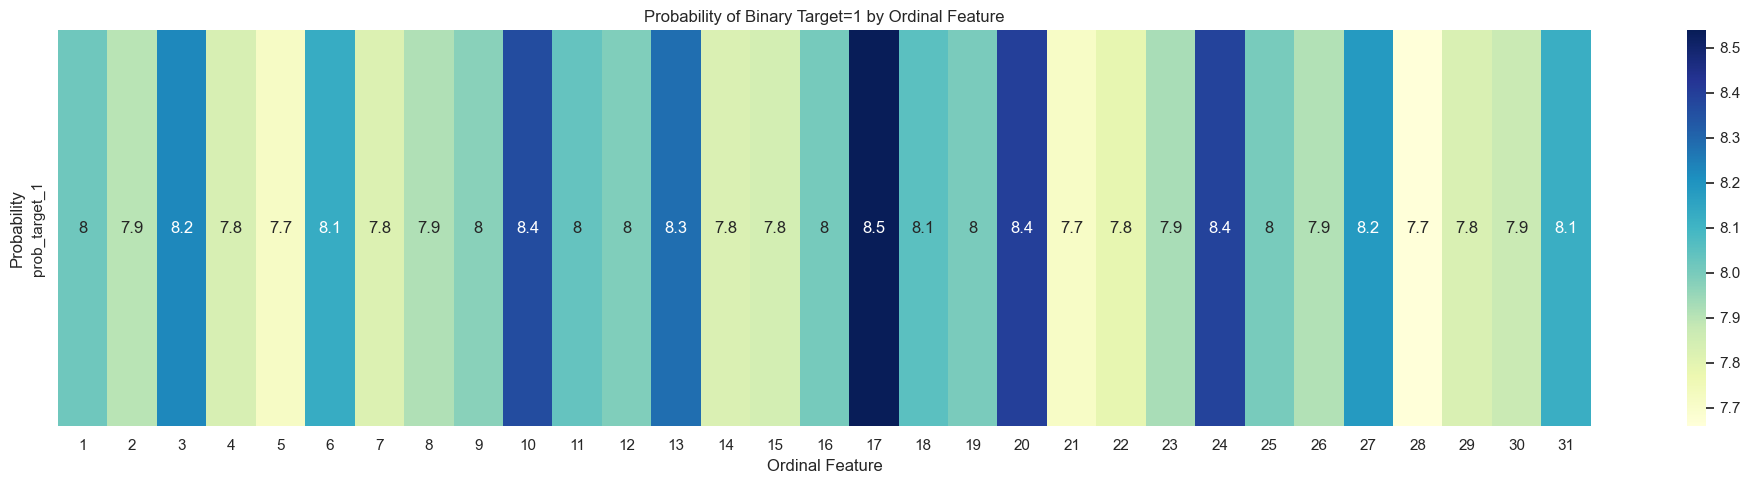

In [34]:
spearmanr_func(Dataset=df_copy2,Numericaltarget="price",OrdinalFeature="DayOfMonth");

W = -0.030, p = 0.296
As The P-value is more than .05 : Fail to reject H₀ → No significant monotonic relationship between price & month


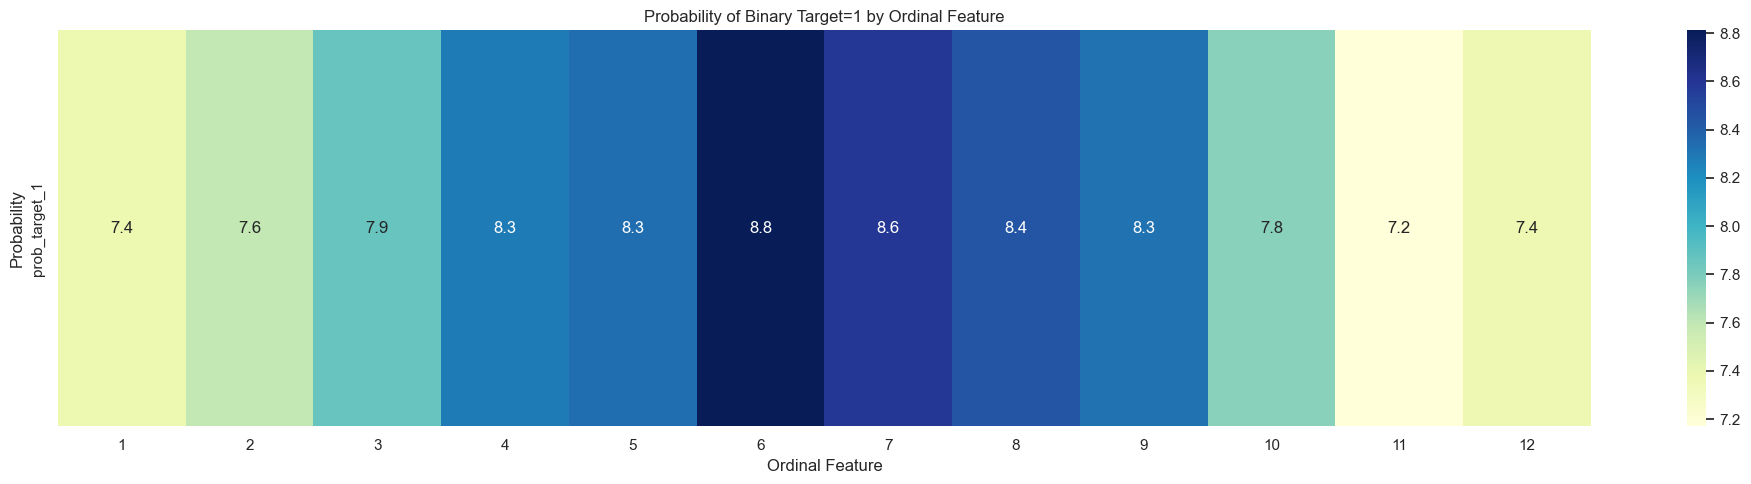

In [35]:
spearmanr_func(Dataset=df_copy2,Numericaltarget="price",OrdinalFeature="month")

W = -0.008, p = 0.777
As The P-value is more than .05 : Fail to reject H₀ → No significant monotonic relationship between price & year


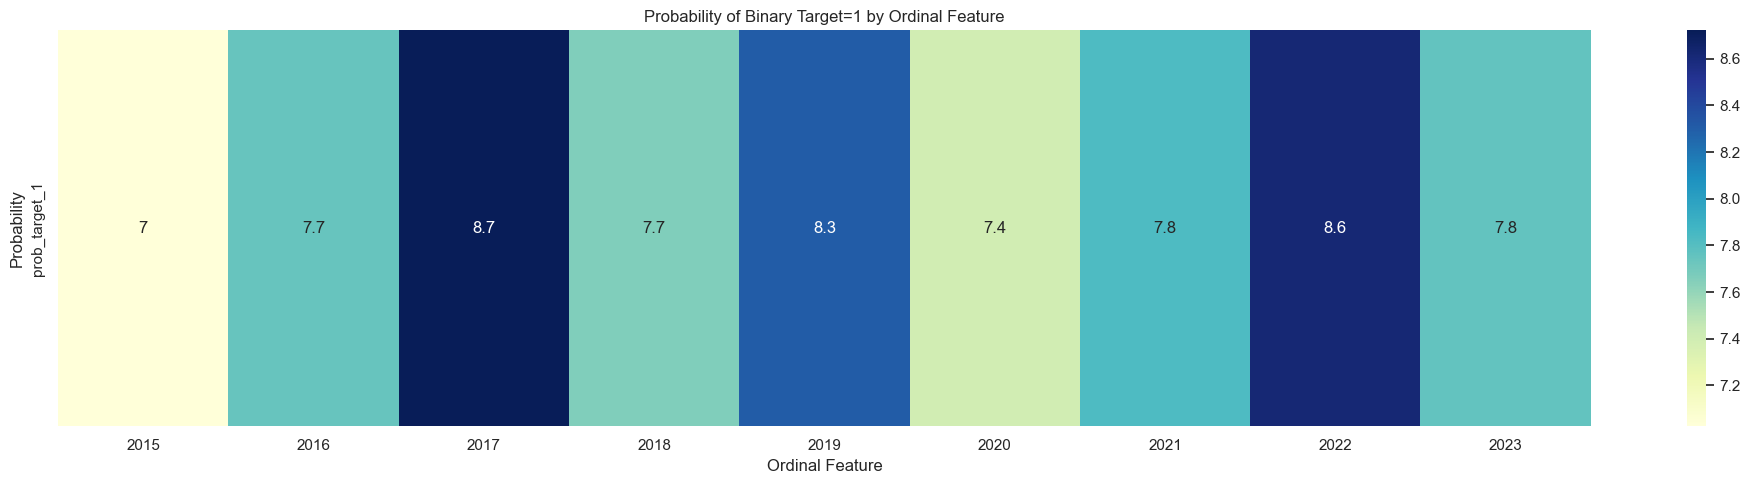

In [36]:
spearmanr_func(Dataset=df_copy2,Numericaltarget="price",OrdinalFeature="year");

* *Kruskal-Wallis test--> non-parametric statistical test used when we have non-normaly distributed target feature and Categorical inpute Feature then have more than 2 categories to*

Kruskal-Wallis Test: Statistic=403.2829742894938, P-value=2.6804938199633663e-88 ==>
 The p value less than 0.05 ==> At least one group has Significant difference


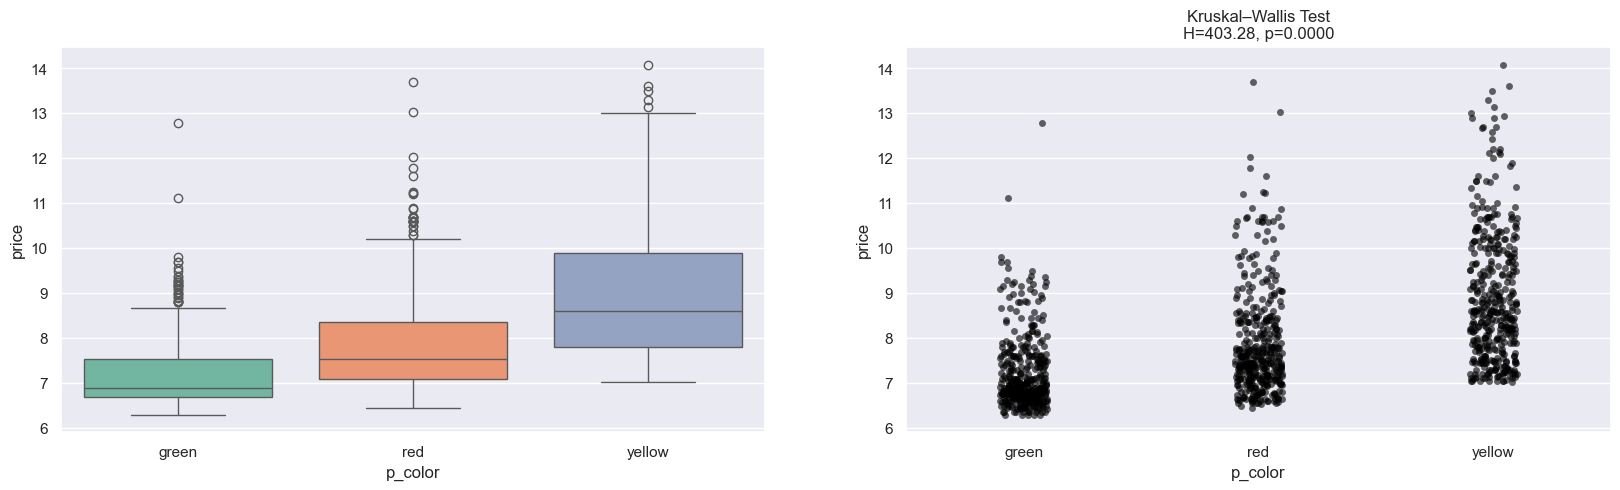

As At least one group has Significant difference --> posthoc_dunn test
               green           red        yellow
green   1.000000e+00  1.455148e-20  4.128064e-89
red     1.455148e-20  1.000000e+00  4.868764e-26
yellow  4.128064e-89  4.868764e-26  1.000000e+00


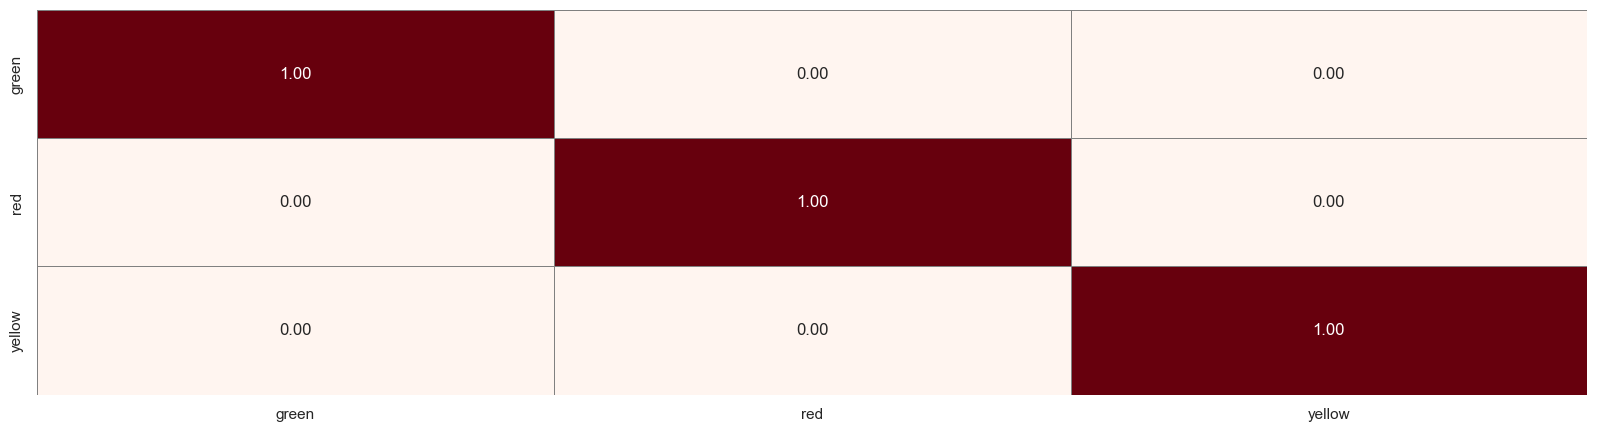

In [37]:
kruskal_func(Dataset=df_copy2,Numericaltarget="price",CategoricalFeature="p_color")

* *When looking at the week_start_dt feature , we see that the data is weekly basis for each p_color*

In [91]:
df_ts=df_copy2.drop('week_end_dt',axis=1)
df_ts=df_ts.rename(columns={'week_start_dt': 'Date'})
df_ts=df_ts.set_index('Date')
df_ts.head()

,vietnam_season,p_color,price,total_volume,brazil,india,vietnam,indonesia,china,brazil_season,indonesia_season,india_season,china_season,jordan_max_price,jordan_min_price,demand,supply,month,year,DayOfMonth
Date,,,,,,,,,,,,,,,,,,,,
2015-12-28,2,green,6.599075,1596040.2,10793.5,65658.1,1519588.5,0.0,0.0,0,0,0,0,6.625,6.325,0.50,0.5,12,2015,28
2015-12-28,2,red,7.175335,1596040.2,10793.5,65658.1,1519588.5,0.0,0.0,0,0,0,0,7.525,7.125,0.51,0.5,12,2015,28
2015-12-28,2,yellow,7.300575,1596040.2,10793.5,65658.1,1519588.5,0.0,0.0,0,0,0,0,7.425,7.025,16.55,0.5,12,2015,28
2016-01-04,2,yellow,7.379675,2295578.0,5677.8,15274.4,2274625.7,0.0,0.0,0,0,0,0,7.525,7.025,271.16,0.5,1,2016,4
2016-01-04,2,red,7.175335,2295578.0,5677.8,15274.4,2274625.7,0.0,0.0,0,0,0,0,7.625,7.125,42.33,0.5,1,2016,4


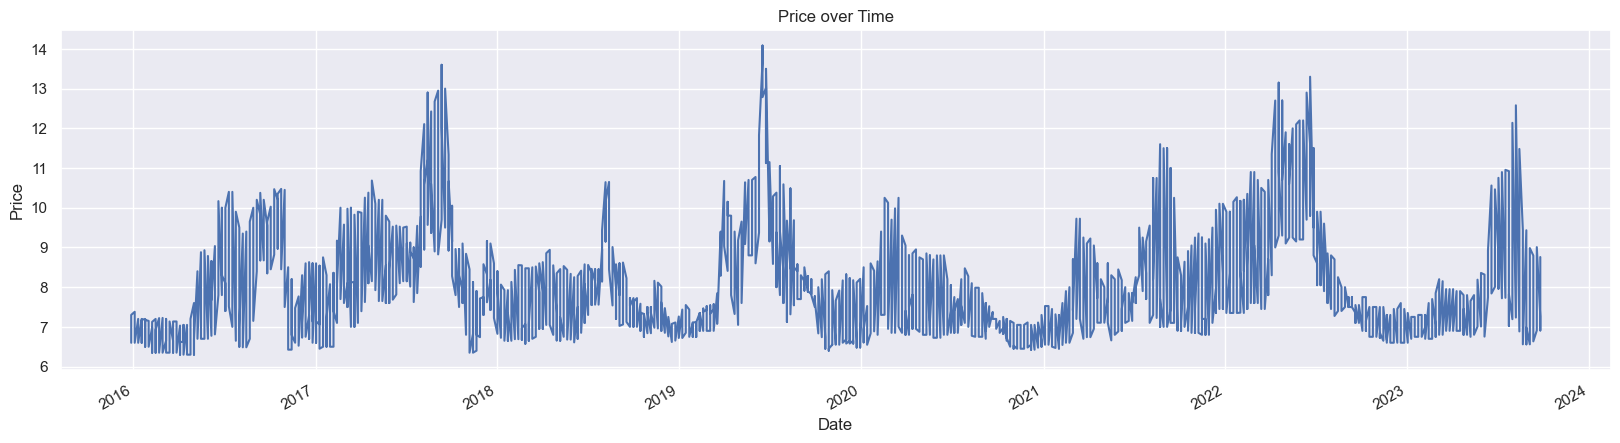

In [39]:
plt.subplots(figsize=(20,5))
color_map = {'red': 'red', 'yellow': 'yellow', 'green': 'green'}
colors = [color_map[cat] for cat in df_ts['p_color']]
df_ts["price"].plot(title="Price over Time",ylabel="Price",xlabel="Date");

* *We will seperate the dataset based on the p_color and apply resmapling*

In [92]:
df_ts_red=df_ts[df_ts["p_color"]=="red"]
df_ts_green=df_ts[df_ts["p_color"]=="green"]
df_ts_yellow=df_ts[df_ts["p_color"]=="yellow"]

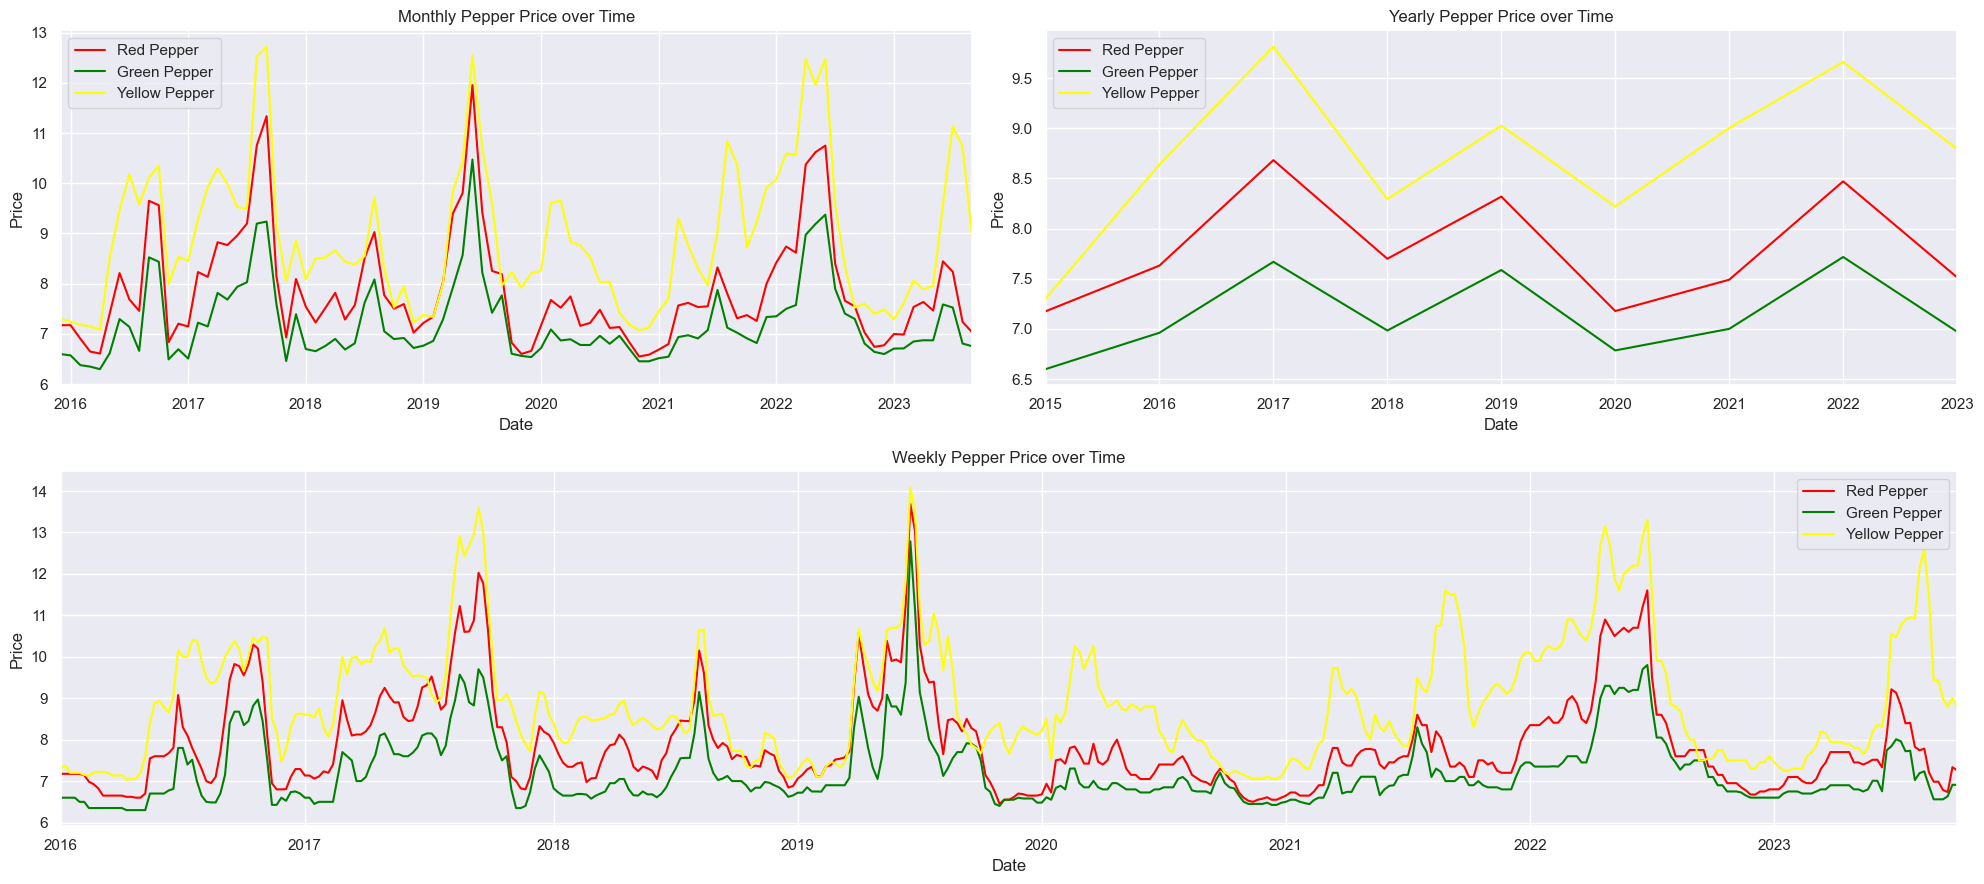

In [41]:
%matplotlib inline 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(20, 9))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
df_ts_red["price"].resample('M').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='red');
df_ts_green["price"].resample('M').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='green');
df_ts_yellow["price"].resample('M').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='yellow');
ax1.set_title("Monthly Pepper Price over Time")
ax1.legend(['Red Pepper', 'Green Pepper', 'Yellow Pepper'])

ax2 = fig.add_subplot(gs[0, 1])
df_ts_red["price"].resample('Y').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='red');
df_ts_green["price"].resample('Y').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='green');
df_ts_yellow["price"].resample('Y').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='yellow');
ax2.set_title("Yearly Pepper Price over Time")
ax2.legend(['Red Pepper', 'Green Pepper', 'Yellow Pepper'])

ax3 = fig.add_subplot(gs[1, :])
df_ts_red["price"].resample('W').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='red');
df_ts_green["price"].resample('W').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='green');
df_ts_yellow["price"].resample('W').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='yellow');
ax3.set_title("Weekly Pepper Price over Time")
ax3.legend(['Red Pepper', 'Green Pepper', 'Yellow Pepper'])


plt.tight_layout()
plt.show()

In [67]:
pd.pivot_table(data=pd.DataFrame(df_copy.groupby(["p_color","year"])["price"].agg(['min','mean','max'])).reset_index(),index='year',columns='p_color',values=['min','mean','max'] )

max                            mean                      \
p_color      green        red     yellow     green       red    yellow   
year                                                                     
2015      6.599075   7.175335   7.300575  6.599075  7.175335  7.300575   
2016      8.969815  10.295265  10.474745  6.961848  7.630899  8.637669   
2017      9.699975  12.025475  13.600505  7.668789  8.681479  9.813603   
2018      9.149830  10.150460  10.650240  6.983981  7.698913  8.293208   
2019     12.784810  13.685380  14.084590  7.586659  8.317951  9.025108   
2020      7.305010   7.999920  10.250070  6.785509  7.178296  8.219889   
2021      8.300540   8.599950  11.600420  7.000649  7.490333  9.001985   
2022      9.800270  11.600320  13.300160  7.716489  8.470593  9.659391   
2023      8.009530   9.213480  12.579919  6.971917  7.513677  8.792197   

              min                      
p_color     green       red    yellow  
year                                   
2015     6.599075  7.175335  7.300575  
2016     6.299625  6.600165  7.031635  
2017     6.349525  6.799845  7.715465  
2018     6.575525  6.845210  7.074920  
2019     6.400310  6.449990  7.102040  
2020     6.424740  6.500410  7.049910  
2021     6.445080  6.649570  7.299640  
2022     6.600445  6.674985  7.300195  
2023     6.560342  6.735184  7.250475

In [68]:
pd.pivot_table(data=pd.DataFrame(df_copy.groupby(["p_color","month"])["price"].agg(['min','mean','max'])).reset_index(),index='month',columns='p_color',values=['min','mean','max'] )

max                            mean                      \
p_color      green        red     yellow     green       red    yellow   
month                                                                    
1         7.357210   8.550230  10.264760  6.740997  7.321932  8.080606   
2         7.699695   9.049910  10.900040  6.856549  7.471550  8.437196   
3         8.285380   9.299570  10.700030  6.969322  7.689205  8.934166   
4         9.299680  10.899720  13.149870  7.337420  8.274296  9.233267   
5         9.249960  10.699710  12.199540  7.420718  8.271086  9.302255   
6        12.784810  13.685380  14.084590  7.882834  8.784116  9.768111   
7         9.149600  10.299900  12.138784  7.682068  8.457099  9.626608   
8         9.568895  11.225435  12.899905  7.390267  8.092032  9.842566   
9         9.699975  12.025475  13.600505  7.583816  8.245302  9.124871   
10        8.969815  10.295265  10.474745  7.175328  7.669163  8.433553   
11        6.979100   7.744690   9.350590  6.623420  6.930077  7.956783   
12        7.619645   8.350220  10.102040  6.801210  7.170094  8.135243   

              min                      
p_color     green       red    yellow  
month                                  
1        6.449915  6.649570  7.102040  
2        6.349345  6.649570  7.115600  
3        6.350475  6.649885  7.135595  
4        6.299625  6.600165  7.031635  
5        6.299625  6.699605  7.600025  
6        6.609760  7.049590  7.849950  
7        6.649925  7.299635  7.699660  
8        6.484945  6.950465  7.849950  
9        6.560342  6.735184  7.200200  
10       6.400310  6.449990  7.150480  
11       6.349525  6.500410  7.049910  
12       6.424740  6.550130  7.049910

* *Red Pepper Price*

In [69]:
new_df_ts_red=df_ts_red["price"].resample('M').mean().to_frame().reset_index('Date')
new_df_ts_red["month"]=new_df_ts_red["Date"].dt.month
new_df_ts_red["year"]=new_df_ts_red["Date"].dt.year

In [73]:
pd.DataFrame(df_ts_red.groupby(["year"])["price"].agg(['min','mean','max'])).reset_index()

,year,min,mean,max
0,2015,7.175335,7.175335,7.175335
1,2016,6.600165,7.630899,10.295265
2,2017,6.799845,8.681479,12.025475
3,2018,6.845210,7.698913,10.150460
4,2019,6.449990,8.317951,13.685380
5,2020,6.500410,7.178296,7.999920
6,2021,6.649570,7.490333,8.599950
7,2022,6.674985,8.470593,11.600320
8,2023,6.735184,7.513677,9.213480


In [74]:
pd.DataFrame(df_ts_red.groupby(["month"])["price"].agg(['min','mean','max'])).reset_index()

,month,min,mean,max
0,1,6.649570,7.321932,8.550230
1,2,6.649570,7.471550,9.049910
2,3,6.649885,7.689205,9.299570
3,4,6.600165,8.274296,10.899720
4,5,6.699605,8.271086,10.699710
5,6,7.049590,8.784116,13.685380
6,7,7.299635,8.457099,10.299900
7,8,6.950465,8.092032,11.225435
8,9,6.735184,8.245302,12.025475
9,10,6.449990,7.669163,10.295265


In [71]:
pd.DataFrame(df_ts_red.groupby(["year","month"])["price"].agg(['min','mean','max'])).reset_index().sort_values(by="mean",ascending=False).head(10)

,year,month,min,mean,max
42,2019,6,9.864850,11.953655,13.685380
21,2017,9,10.664955,11.335045,12.025475
20,2017,8,10.580205,10.753942,11.225435
78,2022,6,9.499650,10.749995,11.600320
77,2022,5,10.499700,10.619932,10.699710
76,2022,4,9.400210,10.374835,10.899720
41,2019,5,9.000400,9.804960,10.384650
9,2016,9,9.450025,9.650317,9.825185
10,2016,10,8.099675,9.563477,10.295265
43,2019,7,8.400370,9.426184,10.299900


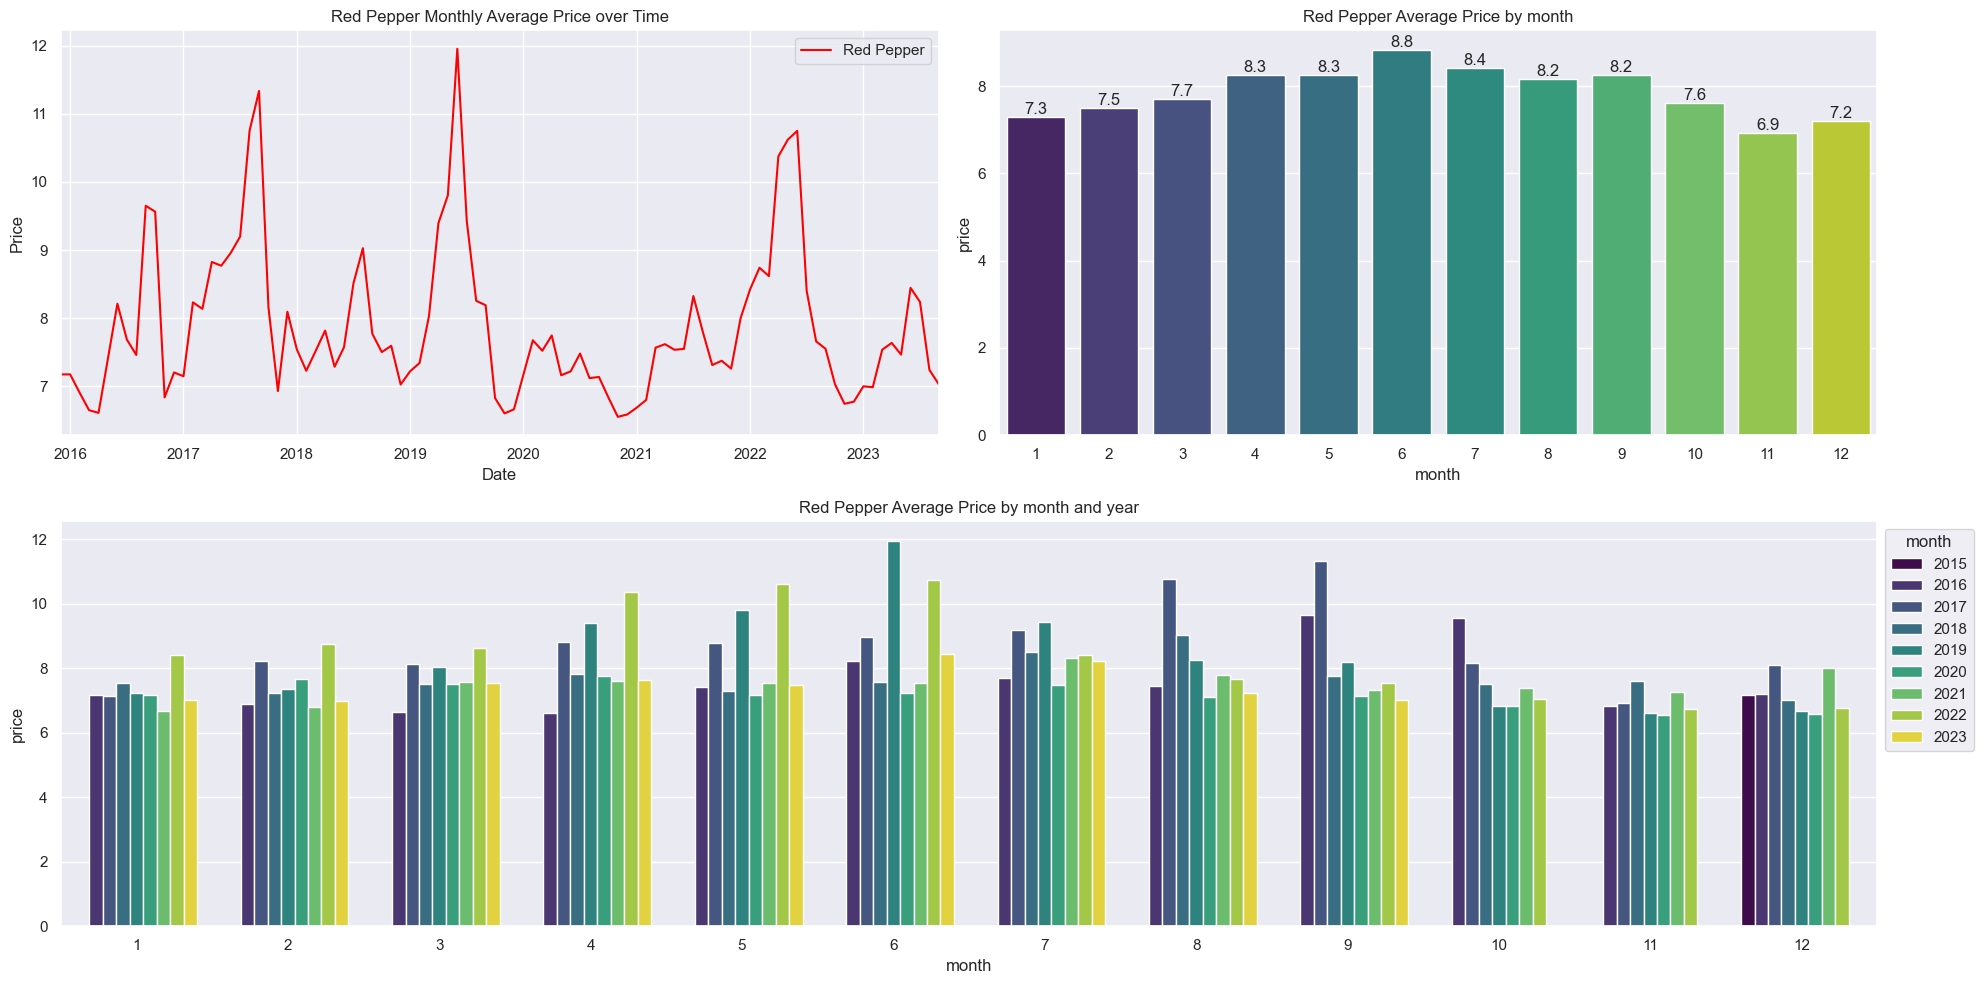

In [80]:
%matplotlib inline 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
df_ts_red["price"].resample('M').mean().plot(title="Red Pepper Price over Time",ylabel="Price",xlabel="Date",color='red');
ax1.set_title("Red Pepper Monthly Average Price over Time")
ax1.legend(['Red Pepper'])

ax2 = fig.add_subplot(gs[0, 1])
ax2=sns.barplot(data=new_df_ts_red, x="month", y="price", palette="viridis",errorbar=None)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', label_type="edge")
ax2.set_title("Red Pepper Average Price by month")

ax3 = fig.add_subplot(gs[1, :])
ax3=sns.barplot(data=new_df_ts_red, x="month", y="price", hue="year",palette="viridis",legend=[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])
ax3.set_title("Red Pepper Average Price by month and year")
ax3.legend(title='month', bbox_to_anchor=(1, 1), loc='upper left');


plt.tight_layout()
plt.show()

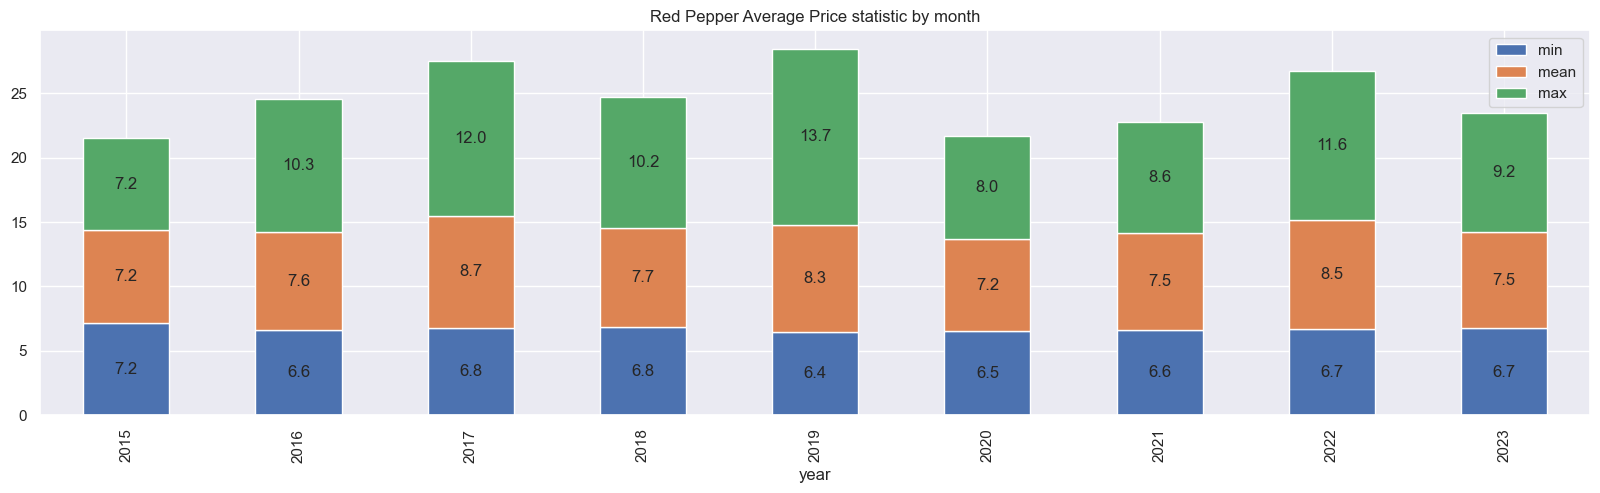

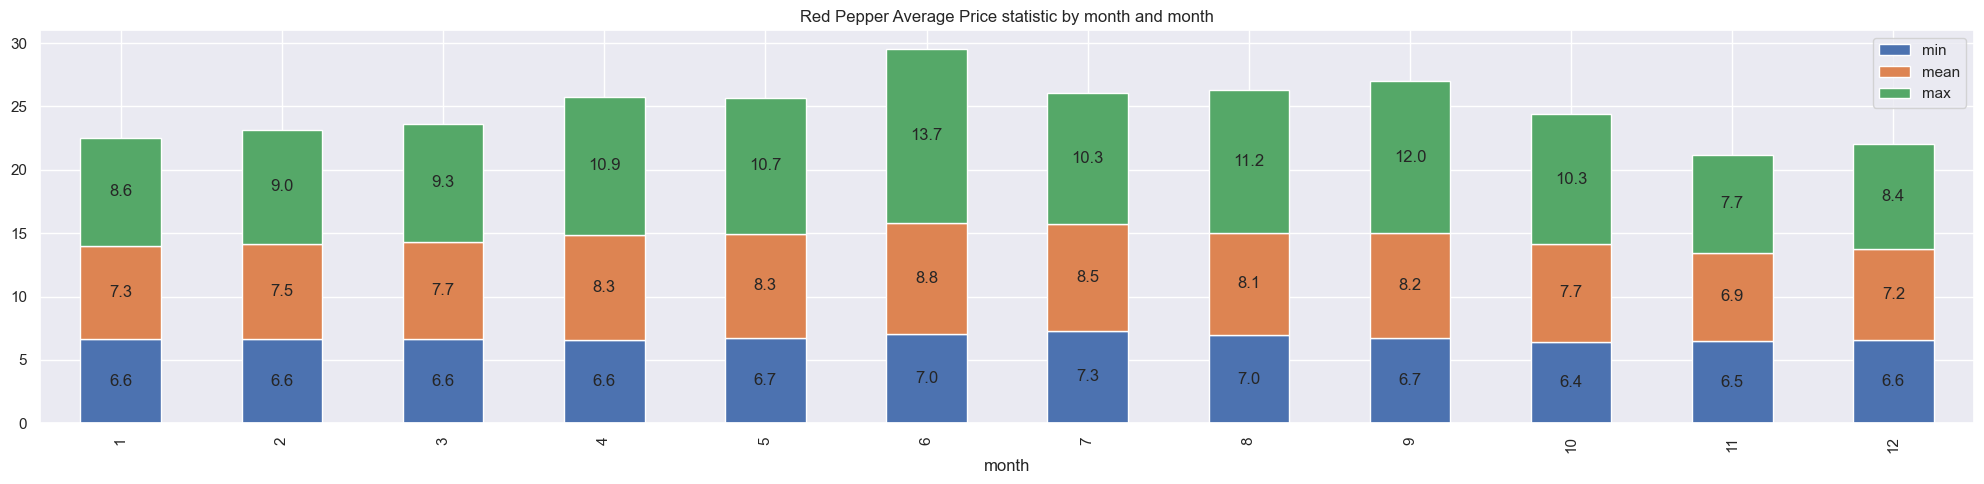

In [87]:
%matplotlib inline 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
#fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

ax1=pd.DataFrame(df_ts_red.groupby("year")["price"].agg(['min','mean','max'])).plot(kind="bar",
                                                                                            stacked=True,
                                                                                            figsize=(20, 5),
                                                                                            title='Red Pepper Average Price statistic by month')
ax2=pd.DataFrame(df_ts_red.groupby("month")["price"].agg(['min','mean','max'])).plot(kind="bar",
                                                                                            stacked=True,
                                                                                            figsize=(20, 5),
                                                                                            title='Red Pepper Average Price statistic by month and month')


for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f', label_type='center')

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', label_type='center')


plt.tight_layout()
plt.show()

W = 10505.500, p = 0.000
As The P-value is less than .05 : Reject H₀ → There is significant distribution difference between price & brazil_season
W = 8857.000, p = 0.000
As The P-value is less than .05 : Reject H₀ → There is significant distribution difference between price & indonesia_season
W = 13151.000, p = 0.031
As The P-value is less than .05 : Reject H₀ → There is significant distribution difference between price & india_season
W = 10488.000, p = 0.000
As The P-value is less than .05 : Reject H₀ → There is significant distribution difference between price & china_season


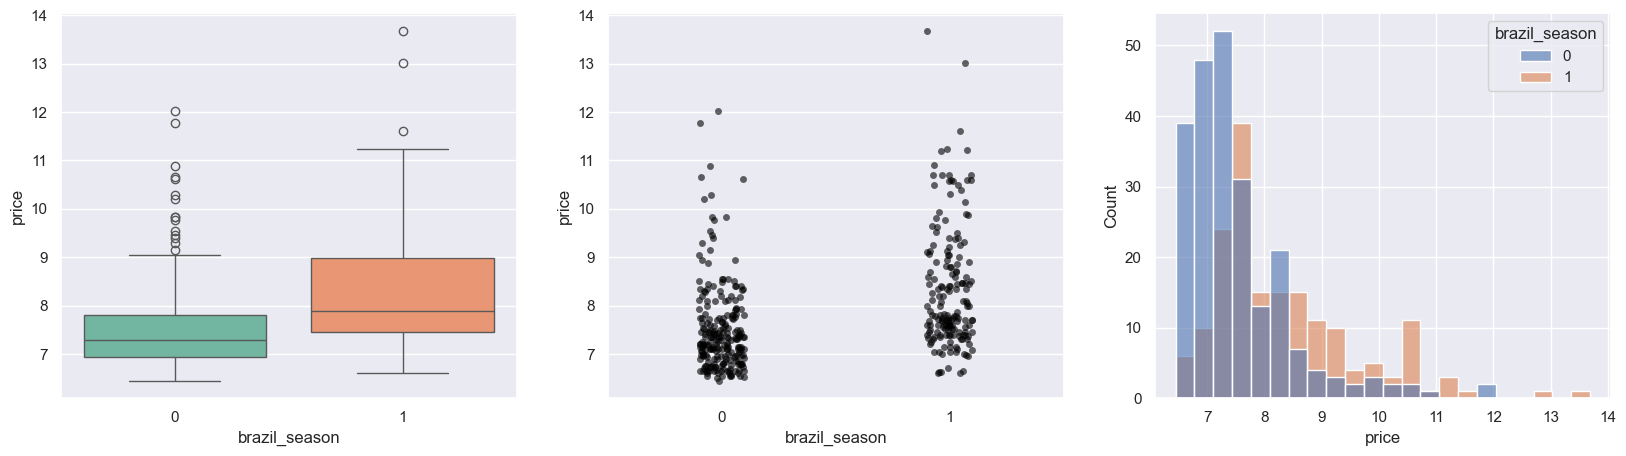

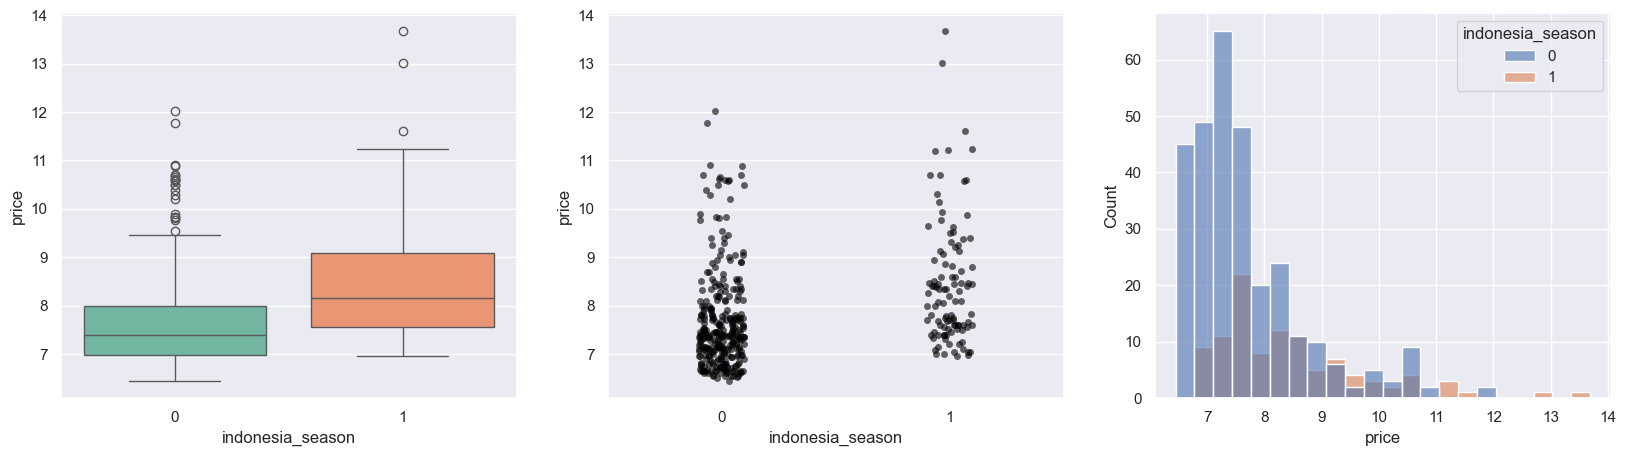

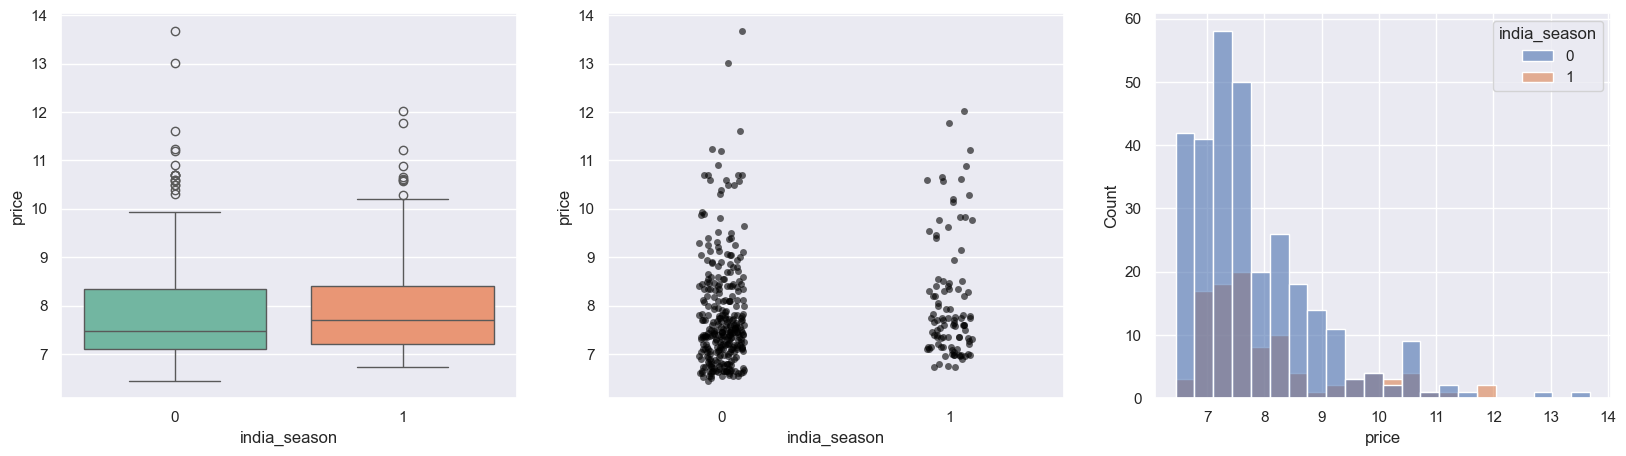

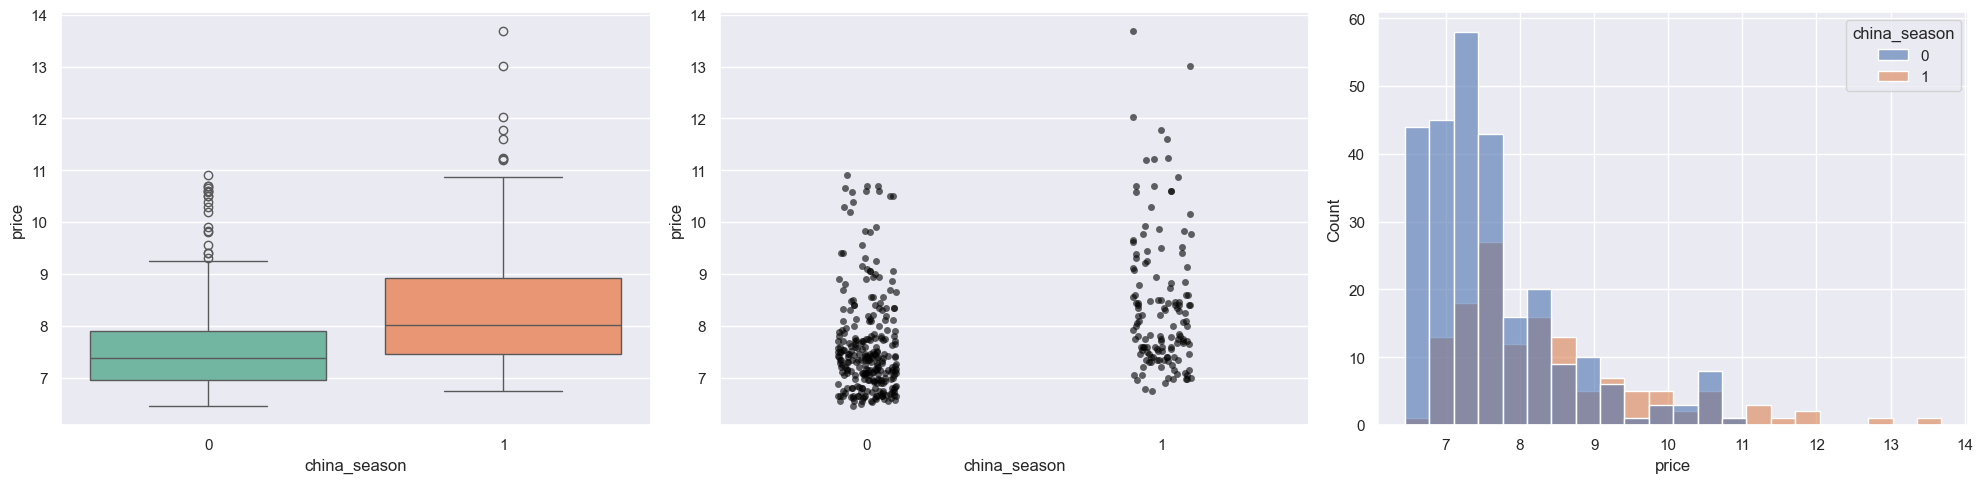

In [88]:
%matplotlib inline 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

ax1=mannwhitneyu_func(Dataset=df_ts_red,Numericaltarget="price",BinaryFeature="brazil_season")
ax2=mannwhitneyu_func(Dataset=df_ts_red,Numericaltarget="price",BinaryFeature="indonesia_season")
ax3=mannwhitneyu_func(Dataset=df_ts_red,Numericaltarget="price",BinaryFeature="india_season")
ax4=mannwhitneyu_func(Dataset=df_ts_red,Numericaltarget="price",BinaryFeature="china_season")


plt.tight_layout()
plt.show()

W = -0.133, p = 0.007
As The P-value is less than .05 : Reject H₀ → There is significant monotonic relationship between price & vietnam_season


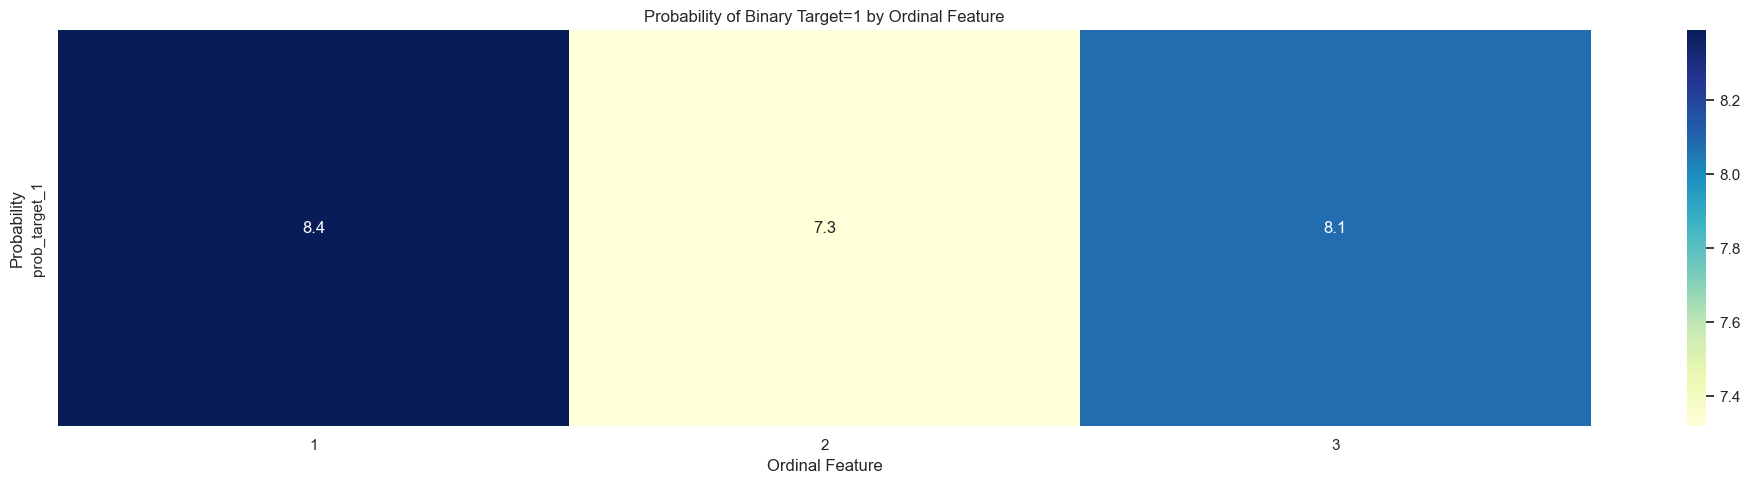

W = -0.116, p = 0.019
As The P-value is less than .05 : Reject H₀ → There is significant monotonic relationship between price & month


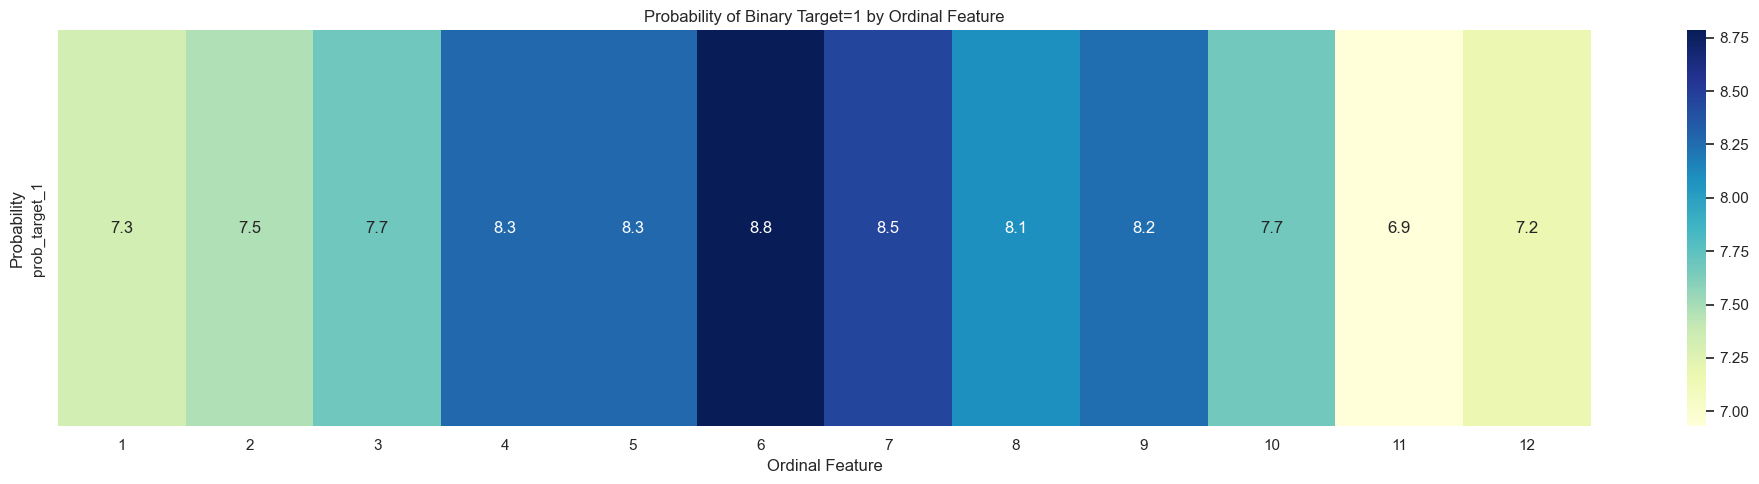

W = -0.051, p = 0.302
As The P-value is more than .05 : Fail to reject H₀ → No significant monotonic relationship between price & year


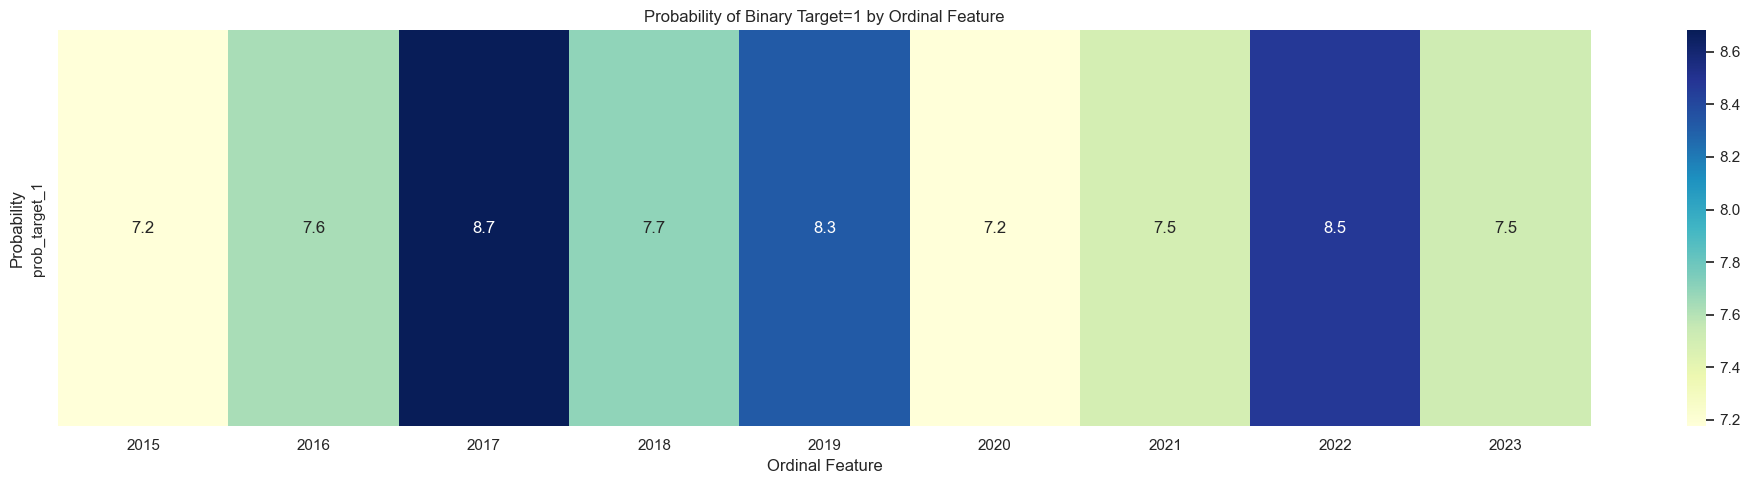

<Figure size 2000x1000 with 0 Axes>

In [89]:
%matplotlib inline 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])

ax1=spearmanr_func(Dataset=df_ts_red,Numericaltarget="price",OrdinalFeature="vietnam_season")
ax2=spearmanr_func(Dataset=df_ts_red,Numericaltarget="price",OrdinalFeature="month")
ax3=spearmanr_func(Dataset=df_ts_red,Numericaltarget="price",OrdinalFeature="year")


plt.tight_layout()
plt.show();

In [100]:
new_df_ts_green=df_ts_green["price"].resample('M').mean().to_frame().reset_index('Date')
new_df_ts_green["month"]=new_df_ts_green["Date"].dt.month
new_df_ts_green["year"]=new_df_ts_green["Date"].dt.year

In [101]:
pd.DataFrame(new_df_ts_green.groupby(["year"])["price"].agg(['min','mean','max'])).reset_index()

,year,min,mean,max
0,2015,6.599075,6.599075,6.599075
1,2016,6.299625,6.956569,8.524877
2,2017,6.459983,7.686565,9.237523
3,2018,6.657450,6.985562,8.085088
4,2019,6.540204,7.584318,10.471418
5,2020,6.455702,6.790308,7.088897
6,2021,6.517682,7.005000,7.875377
7,2022,6.600445,7.718773,9.375108
8,2023,6.709829,6.966526,7.587343


In [102]:
pd.DataFrame(new_df_ts_green.groupby(["month"])["price"].agg(['min','mean','max'])).reset_index()

,month,min,mean,max
0,1,6.509805,6.731394,7.351610
1,2,6.379403,6.871459,7.500155
2,3,6.350475,6.973378,7.575018
3,4,6.299625,7.332706,8.974805
4,5,6.619641,7.415236,9.190070
5,6,6.780012,7.917297,10.471418
6,7,6.962338,7.660839,8.227068
7,8,6.663937,7.439080,9.197125
8,9,6.753917,7.578065,9.237523
9,10,6.606535,7.138165,8.437811


In [103]:
pd.DataFrame(new_df_ts_green.groupby(["year","month"])["price"].agg(['min','mean','max'])).reset_index().sort_values(by="mean",ascending=False).head(10)

,year,month,min,mean,max
42,2019,6,10.471418,10.471418,10.471418
78,2022,6,9.375108,9.375108,9.375108
21,2017,9,9.237523,9.237523,9.237523
20,2017,8,9.197125,9.197125,9.197125
77,2022,5,9.190070,9.190070,9.190070
76,2022,4,8.974805,8.974805,8.974805
41,2019,5,8.571605,8.571605,8.571605
9,2016,9,8.524877,8.524877,8.524877
10,2016,10,8.437811,8.437811,8.437811
43,2019,7,8.227068,8.227068,8.227068


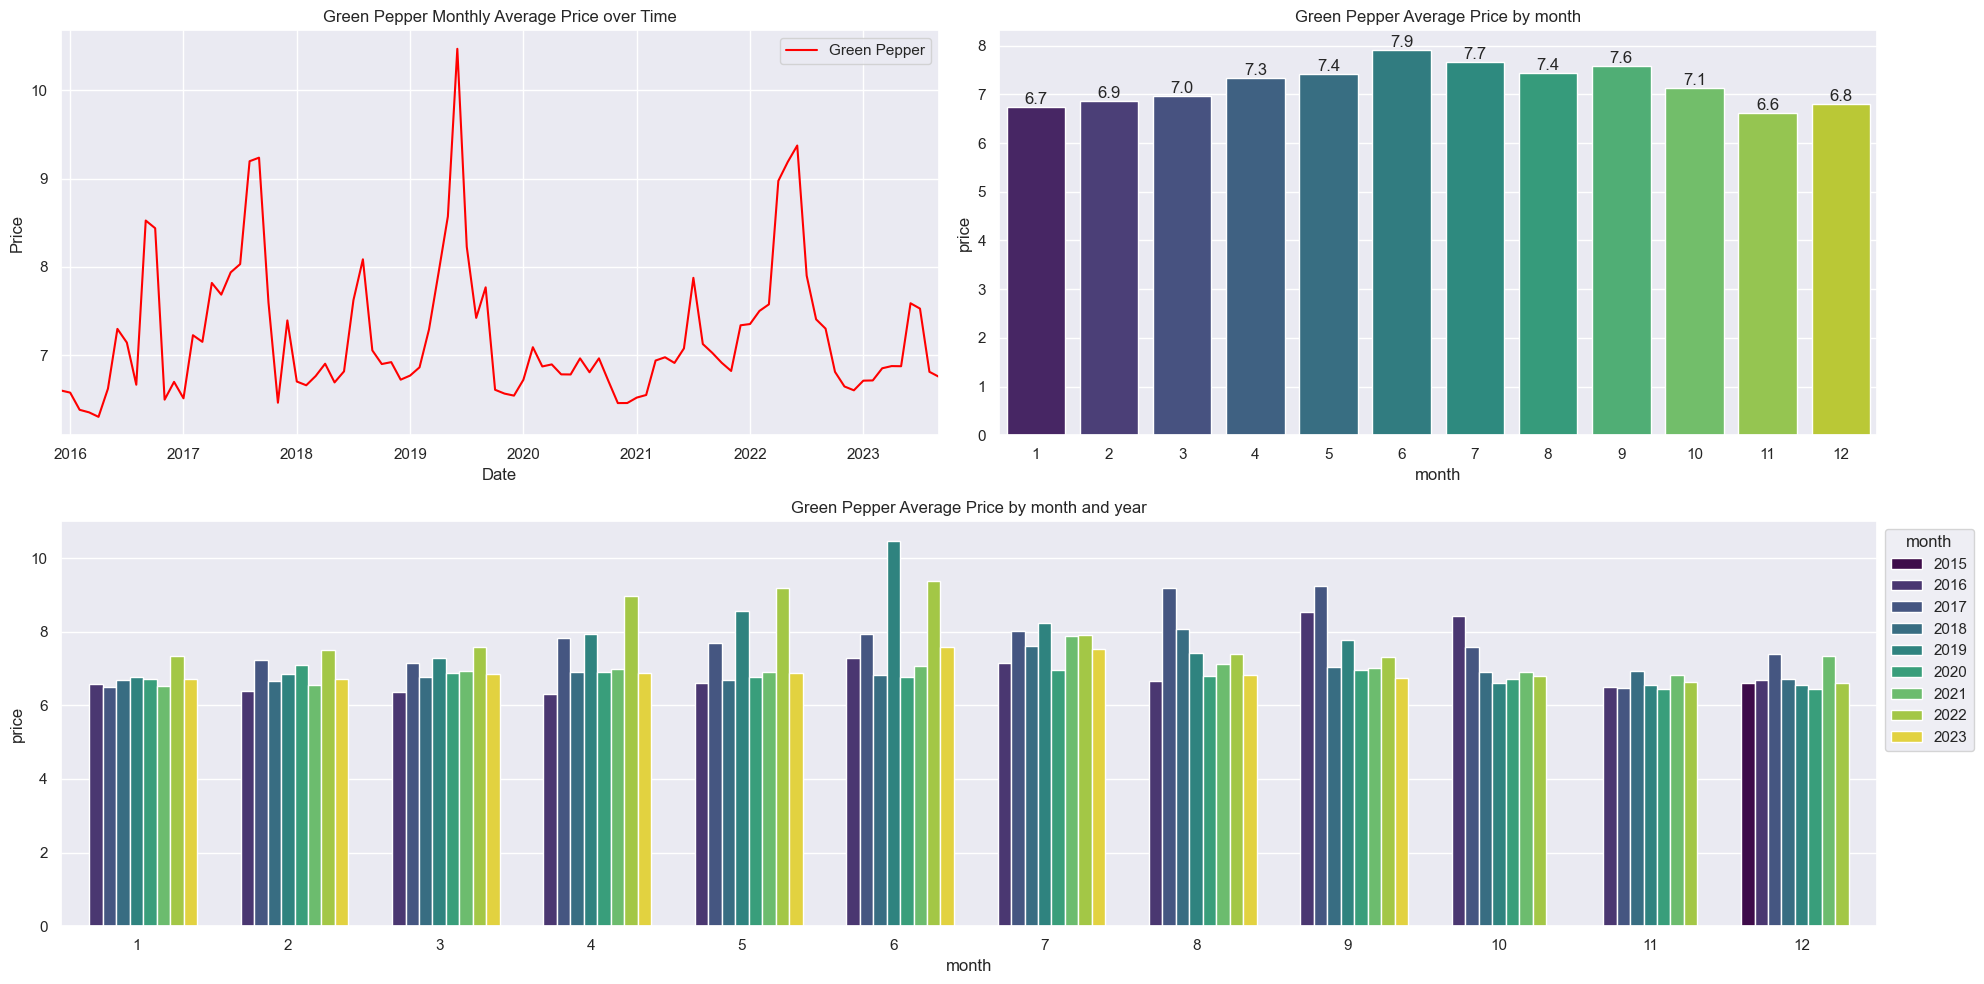

In [110]:
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax1=new_df_ts_green.set_index("Date")["price"].resample('M').mean().plot(title="Green Pepper Price over Time",ylabel="Price",xlabel="Date",color='red');
ax1.set_title("Green Pepper Monthly Average Price over Time")
ax1.legend(['Green Pepper'])

ax2 = fig.add_subplot(gs[0, 1])
ax2=sns.barplot(data=new_df_ts_green, x="month", y="price", palette="viridis",errorbar=None)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', label_type="edge")
ax2.set_title("Green Pepper Average Price by month")

ax3 = fig.add_subplot(gs[1, :])
ax3=sns.barplot(data=new_df_ts_green, x="month", y="price", hue="year",palette="viridis",legend=[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])
ax3.set_title("Green Pepper Average Price by month and year")
ax3.legend(title='month', bbox_to_anchor=(1, 1), loc='upper left');


plt.tight_layout()
plt.show()

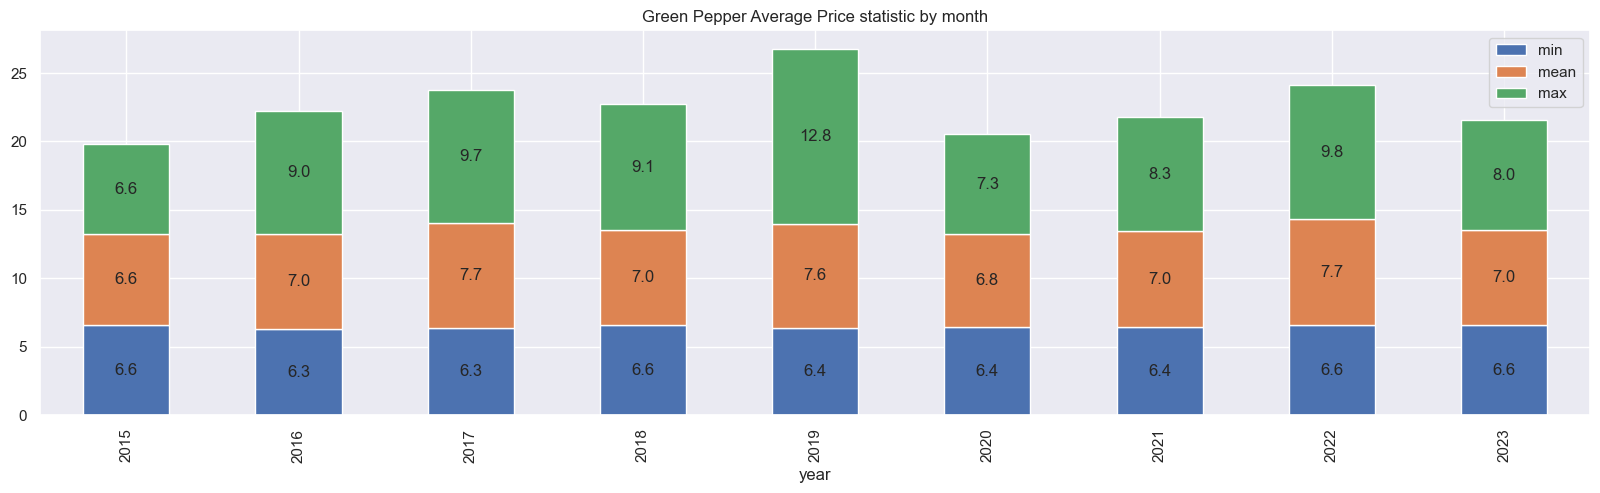

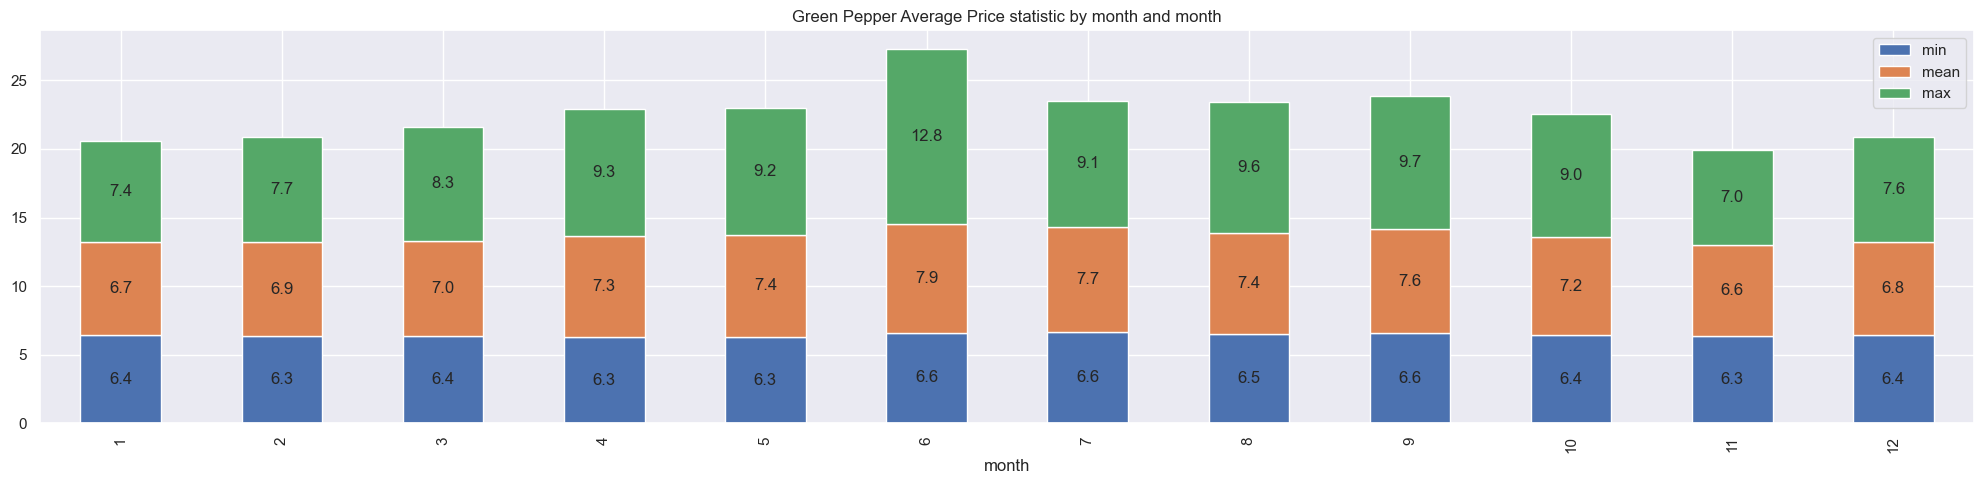

In [111]:
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

ax1=pd.DataFrame(df_ts_green.groupby("year")["price"].agg(['min','mean','max'])).plot(kind="bar",
                                                                                            stacked=True,
                                                                                            figsize=(20, 5),
                                                                                            title='Green Pepper Average Price statistic by month')
ax2=pd.DataFrame(df_ts_green.groupby("month")["price"].agg(['min','mean','max'])).plot(kind="bar",
                                                                                            stacked=True,
                                                                                            figsize=(20, 5),
                                                                                            title='Green Pepper Average Price statistic by month and month')


for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f', label_type='center')

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', label_type='center')

plt.tight_layout()
plt.show()

W = 11773.500, p = 0.000
As The P-value is less than .05 : Reject H₀ → There is significant distribution difference between price & brazil_season
W = 8493.500, p = 0.000
As The P-value is less than .05 : Reject H₀ → There is significant distribution difference between price & indonesia_season
W = 10604.500, p = 0.000
As The P-value is less than .05 : Reject H₀ → There is significant distribution difference between price & india_season
W = 9112.500, p = 0.000
As The P-value is less than .05 : Reject H₀ → There is significant distribution difference between price & china_season


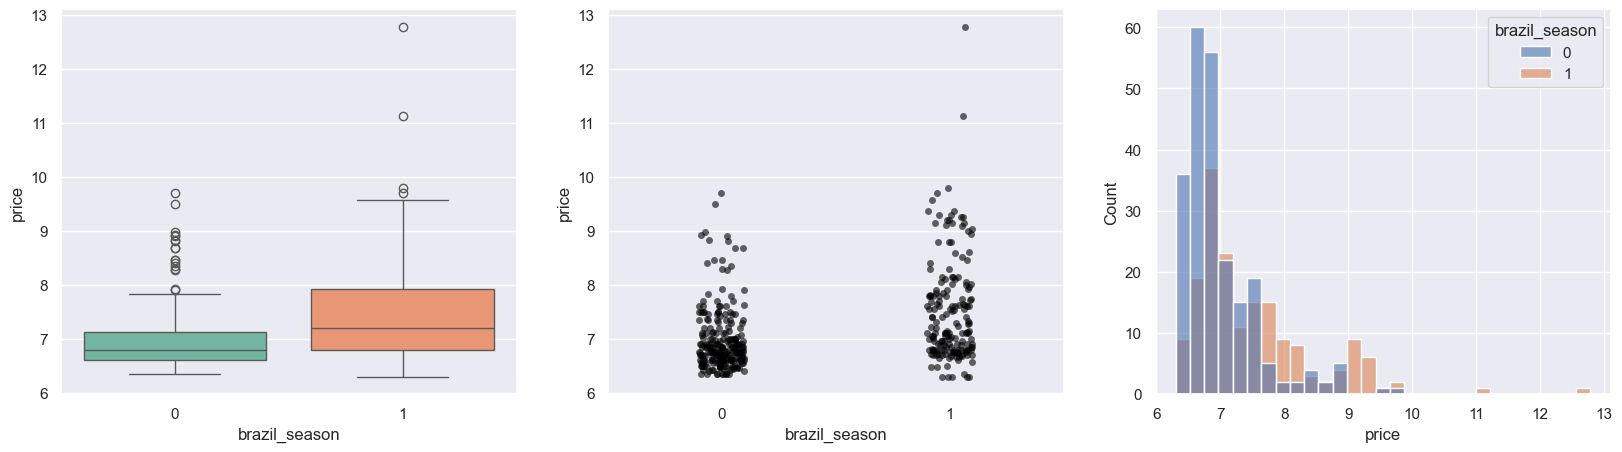

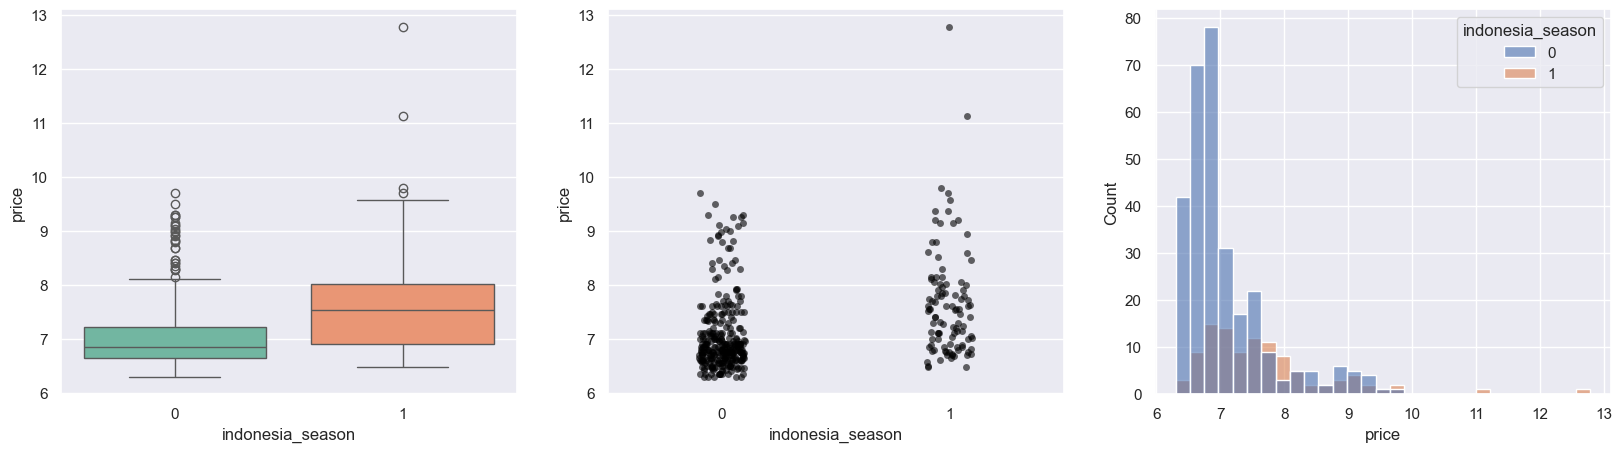

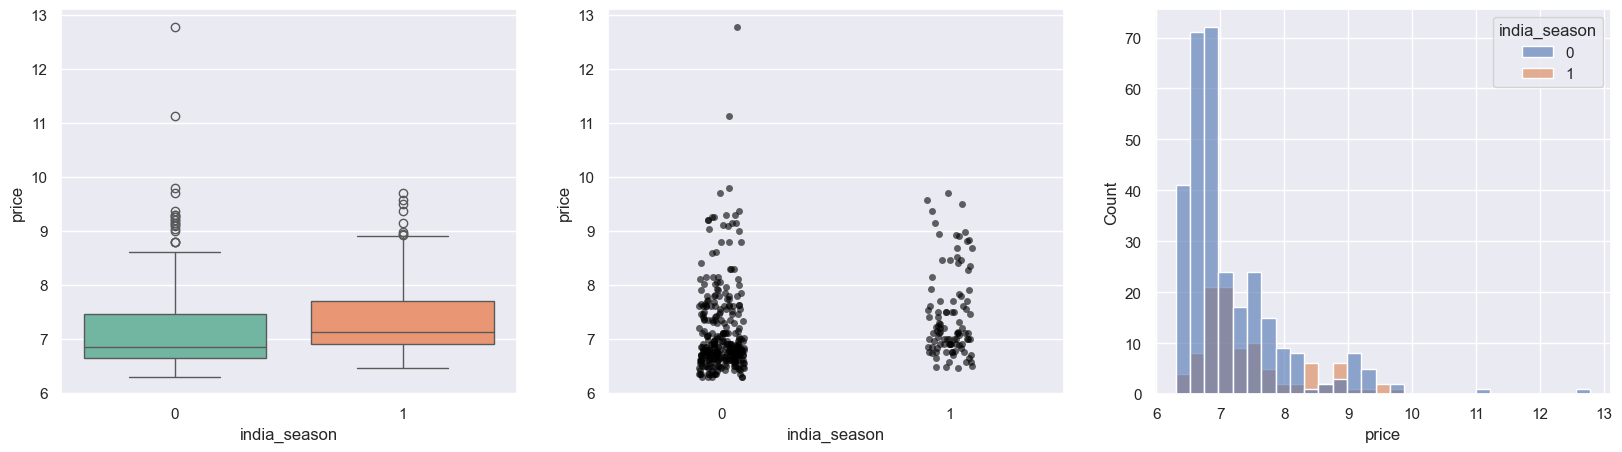

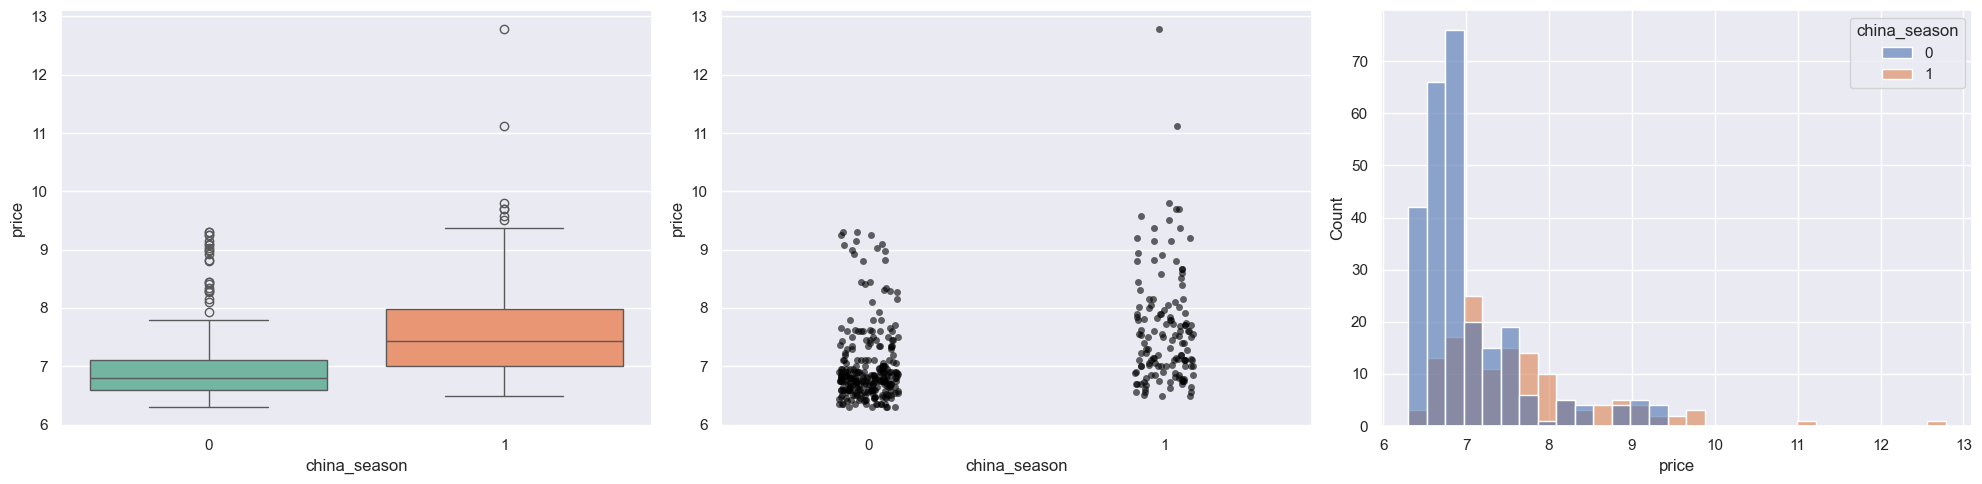

In [116]:
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

ax1=mannwhitneyu_func(Dataset=df_ts_green,Numericaltarget="price",BinaryFeature="brazil_season")
ax2=mannwhitneyu_func(Dataset=df_ts_green,Numericaltarget="price",BinaryFeature="indonesia_season")
ax3=mannwhitneyu_func(Dataset=df_ts_green,Numericaltarget="price",BinaryFeature="india_season")
ax4=mannwhitneyu_func(Dataset=df_ts_green,Numericaltarget="price",BinaryFeature="china_season")


plt.tight_layout()
plt.show()

W = -0.247, p = 0.000
As The P-value is less than .05 : Reject H₀ → There is significant monotonic relationship between price & vietnam_season


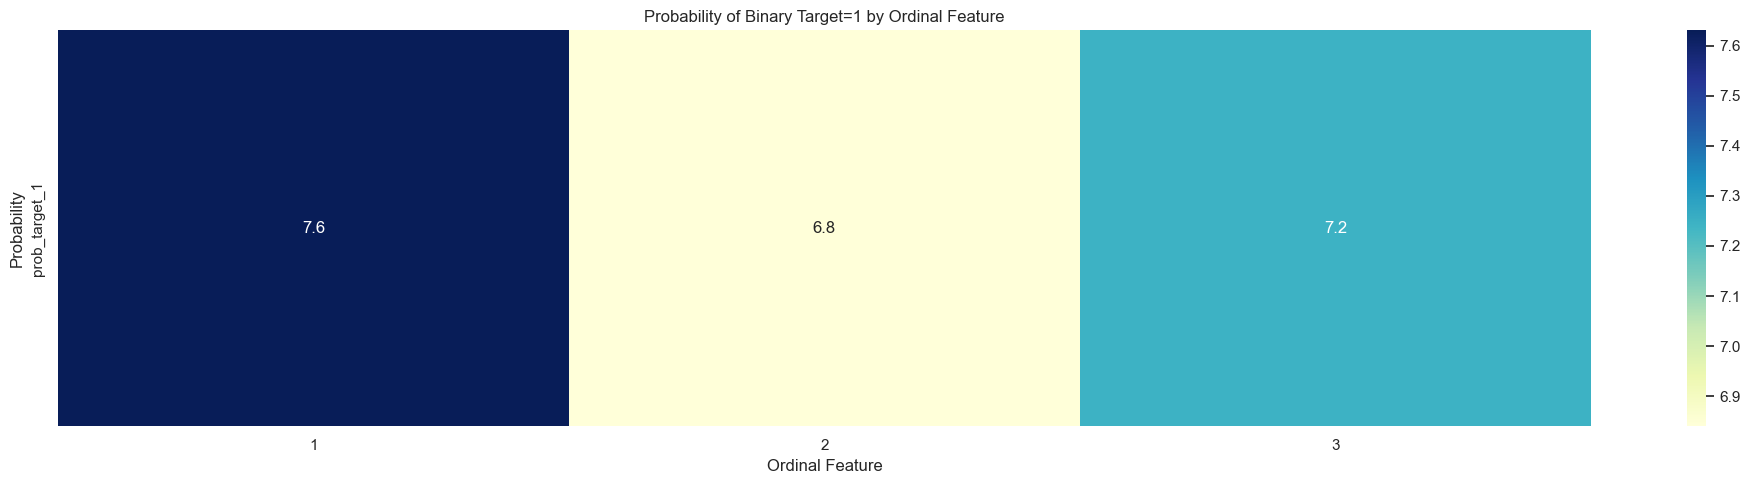

W = 0.038, p = 0.448
As The P-value is more than .05 : Fail to reject H₀ → No significant monotonic relationship between price & month


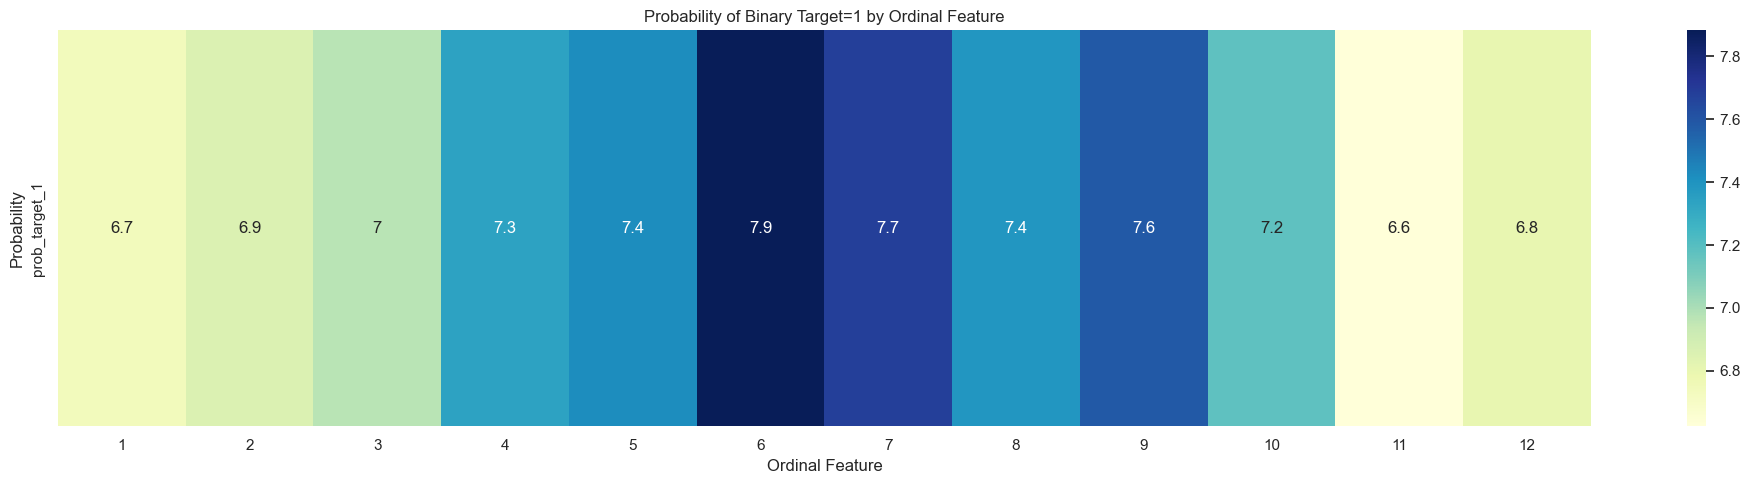

W = 0.093, p = 0.061
As The P-value is more than .05 : Fail to reject H₀ → No significant monotonic relationship between price & year


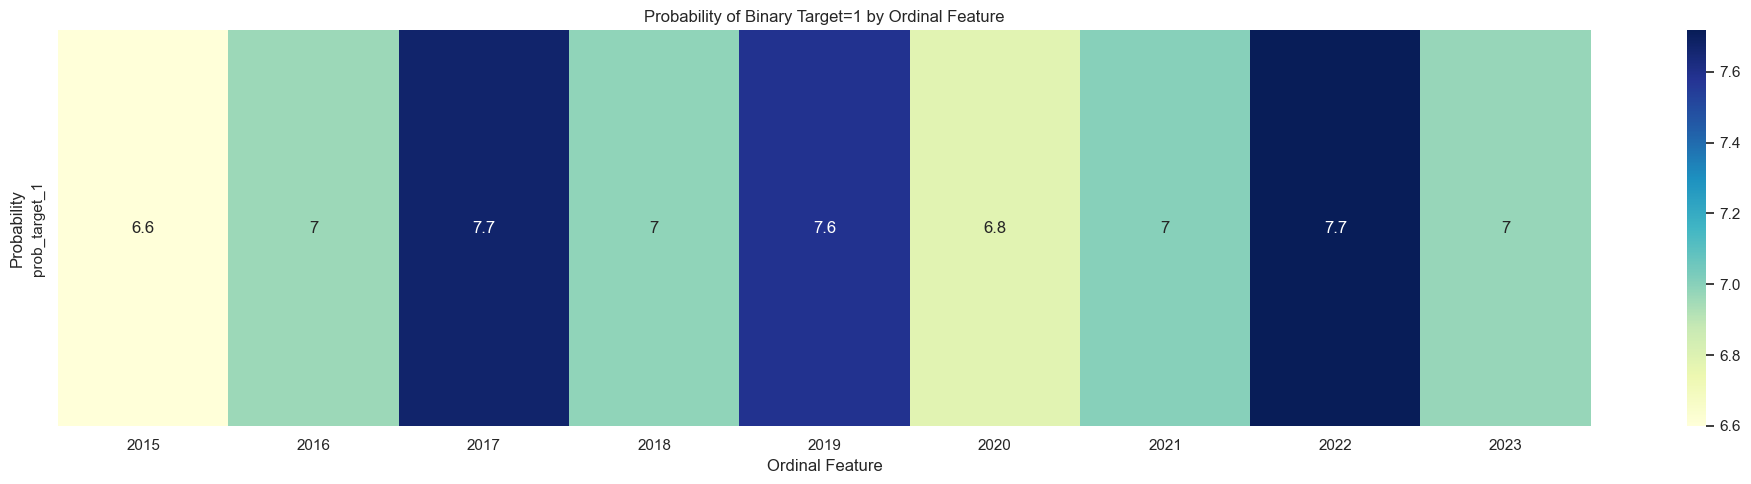

<Figure size 2000x1000 with 0 Axes>

In [114]:
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])

ax1=spearmanr_func(Dataset=df_ts_green,Numericaltarget="price",OrdinalFeature="vietnam_season")
ax2=spearmanr_func(Dataset=df_ts_green,Numericaltarget="price",OrdinalFeature="month")
ax3=spearmanr_func(Dataset=df_ts_green,Numericaltarget="price",OrdinalFeature="year")


plt.tight_layout()
plt.show();

In [154]:
print("Mean Prices for each Pepper Color:")
print(f"the Mean Price for green Pepper is {df_ts_green['price'].resample('Y').mean().mean():.3f}")
print(f"the Mean Price for red Pepper {df_ts_red['price'].resample('Y').mean().mean():.3f}"),
print(f"nthe Mean Price for yellow Pepper is {df_ts_yellow['price'].resample('Y').mean().mean():.3f}")

Mean Prices for each Pepper Color:
the Mean Price for green Pepper is 7.142
the Mean Price for red Pepper 7.795
nthe Mean Price for yellow Pepper is 8.749


In [155]:
print("Mean Prices for each Pepper Color:")
print(f"the Mean Price for green Pepper is {df_ts_green['price'].resample('M').mean().mean():.3f}")
print(f"the Mean Price for red Pepper {df_ts_red['price'].resample('M').mean().mean():.3f}"),
print(f"nthe Mean Price for yellow Pepper is {df_ts_yellow['price'].resample('M').mean().mean():.3f}")

Mean Prices for each Pepper Color:
the Mean Price for green Pepper is 7.213
the Mean Price for red Pepper 7.878
nthe Mean Price for yellow Pepper is 8.919


In [156]:
print("Mean Prices for each Pepper Color:")
print(f"the Mean Price for green Pepper is {df_ts_green['price'].resample('W').mean().mean():.3f}")
print(f"the Mean Price for red Pepper {df_ts_red['price'].resample('W').mean().mean():.3f}"),
print(f"nthe Mean Price for yellow Pepper is {df_ts_yellow['price'].resample('W').mean().mean():.3f}")

Mean Prices for each Pepper Color:
the Mean Price for green Pepper is 7.215
the Mean Price for red Pepper 7.882
nthe Mean Price for yellow Pepper is 8.929


F. Features developments
---> Before diving in , lets look at the features developments during the past time -yearly basis

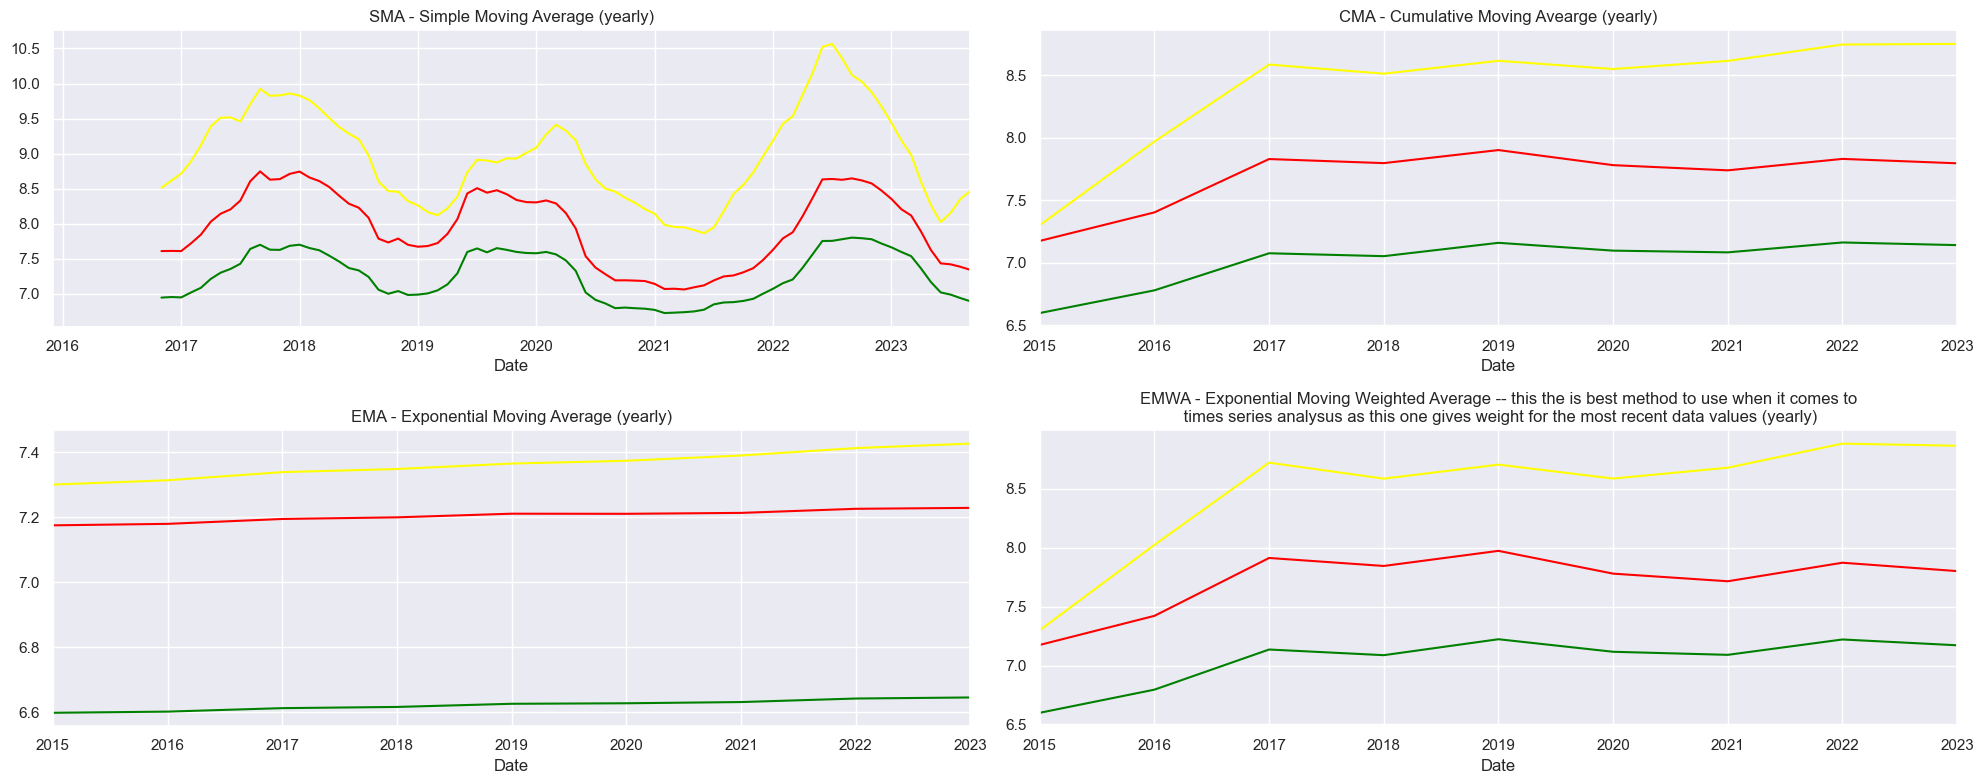

In [160]:
df_ts_red_mean=df_ts_red['price'].resample('M').mean()
df_ts_green_mean=df_ts_green['price'].resample('M').mean()
df_ts_yellow_mean=df_ts_yellow['price'].resample('M').mean()
df_ts_red_mean_YS=df_ts_red['price'].resample(rule="YS").mean()
df_ts_green_mean_YS=df_ts_green['price'].resample(rule="YS").mean()
df_ts_yellow_mean_YS=df_ts_yellow['price'].resample(rule="YS").mean()


fig = plt.figure(figsize=(20, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, 0])
df_ts_red_mean.rolling(window=12).mean().plot(color="red")
df_ts_green_mean.rolling(window=12).mean().plot(color="green")
df_ts_yellow_mean.rolling(window=12).mean().plot(color="yellow");
ax1.set_title("SMA - Simple Moving Average (yearly)")

ax2 = fig.add_subplot(gs[0, 1])
df_ts_red_mean_YS.expanding().mean().plot(color="red")
df_ts_green_mean_YS.expanding().mean().plot(color="green")
df_ts_yellow_mean_YS.expanding().mean().plot(color="yellow");
ax2.set_title("CMA - Cumulative Moving Avearge (yearly)")

ax3 = fig.add_subplot(gs[1, 0])
df_ts_red_mean_YS.ewm(alpha=.01,adjust=False).mean().plot(color="red")
df_ts_green_mean_YS.ewm(alpha=.01,adjust=False).mean().plot(color="green")
df_ts_yellow_mean_YS.ewm(alpha=.01,adjust=False).mean().plot(color="yellow");
ax3.set_title("EMA - Exponential Moving Average (yearly)")


ax4 = fig.add_subplot(gs[1, 1])
df_ts_red_mean_YS.ewm(span=12).mean().plot(color="red")
df_ts_green_mean_YS.ewm(span=12).mean().plot(color="green")
df_ts_yellow_mean_YS.ewm(span=12).mean().plot(color="yellow")
ax4.set_title("EMWA - Exponential Moving Weighted Average -- this the is best method to use when it comes to\n times series analysus as this one gives weight for the most recent data values (yearly)");



plt.tight_layout()
plt.show()